In [29]:
%load_ext autoreload
%autoreload 2

from datetime import date, datetime, timedelta
from functools import partial
from typing import Dict, Optional

import numpy as np
import polars as pl
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from okx.store import OrderbookStore
from okx.features import times_to_dt

from okx.recipes.parity import calculate_synthetics, aggregate_synthetics

from plotting import plot_histogram, plot_over_time_by_group, plot_mean_spread_over_time, plot_dual_axis_over_time

store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
store.clear_cache()

Cleared all caches


In [31]:
def make_dates(start_date, n):
    return [start_date + timedelta(days=i) for i in range(n)]

dates = make_dates(date(2025, 9, 29), 19)
print(f"Dates selected from {dates[0]} to {dates[-1]}")

Dates selected from 2025-09-29 to 2025-10-17


In [32]:
synthetics_5m = calculate_synthetics(
    store,
    inst_family = 'BTC-USD',
    dates = dates,
    binning = '5m',
    assets = 3_000_000,
    volume = 30_000_000,
    verbose = True,
    batch_days = 5,
)

Calculating put-call parity arbitrage opportunities for BTC-USD for 19 dates using 5m binning
[store] Getting BTC-USD/OPTION for 19 dates (depth=1, 5m binning, 7 features)


Processing batches:   0%|          | 0/4 [00:00<?, ?it/s]

[store] Getting BTC-USD/SPOT for 19 dates (depth=0, 5m binning, 4 features)


Processing batches:   0%|          | 0/4 [00:00<?, ?it/s]

 - Time taken to fetch options and spot data: 0:01:41.151568
     VIP 3 options fees: maker=0.0200%, taker=0.0250%
 - Time taken to calculate parity arbitrage: 0:00:00.002064
 - Total time taken for parity arbitrage: 0:01:41.153632


In [33]:
aggregated_5m = times_to_dt(aggregate_synthetics(
    synthetics_5m,
    inst_family = 'BTC-USD',
    max_return = 10.0,
    verbose = True,
)).collect()

Aggregating synthetic forward arbitrage opportunities...
Aggregation complete.


In [34]:
def plot(df, expiry):
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(2, 1, height_ratios=[3, 1])  # Make second plot less tall
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    # Main plot
    ax1.plot(df['timeMs'], df['long_fwd'], label='synthetic long', color='green')
    ax1.plot(df['timeMs'], df['short_fwd'], label='synthetic short', color='red')
    ax1.plot(df['timeMs'], df['BTC-USD'], label='BTC-USD', linestyle=':', linewidth=1, color='black')
    ax1.set_ylabel('Synthetic Forward Price')
    ax1.set_title(f'Best Synthetic Future Prices Over Time (expiry {expiry})')
    ax1.legend()

    # Profit plot
    ax2.plot(df['timeMs'], df['profit_per_unit'], label='profit')
    ax2.set_ylabel('Profit')
    ax2.set_title('Profit Over Time')
    ax2.legend()

    plt.tight_layout()
    plt.show()

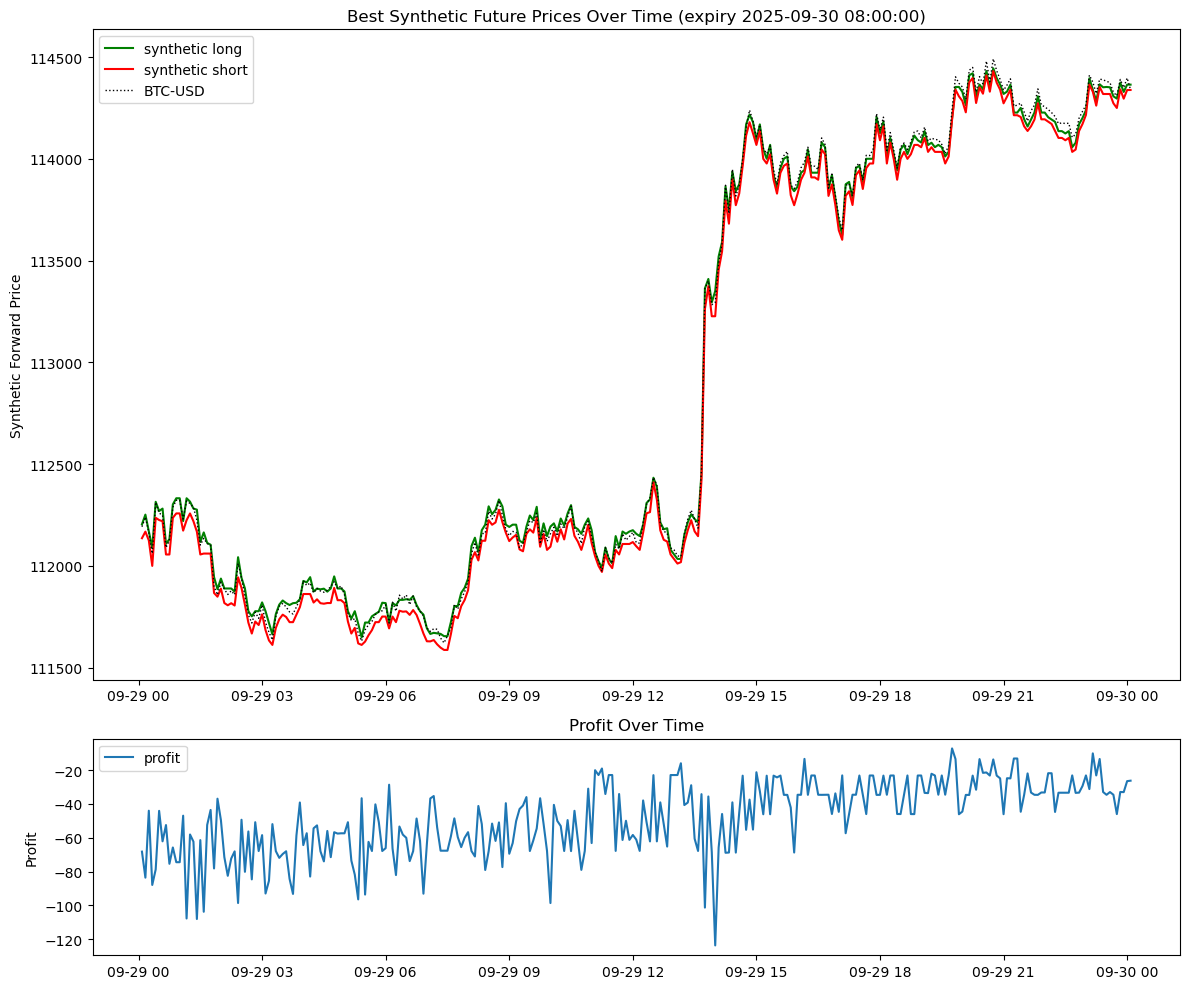

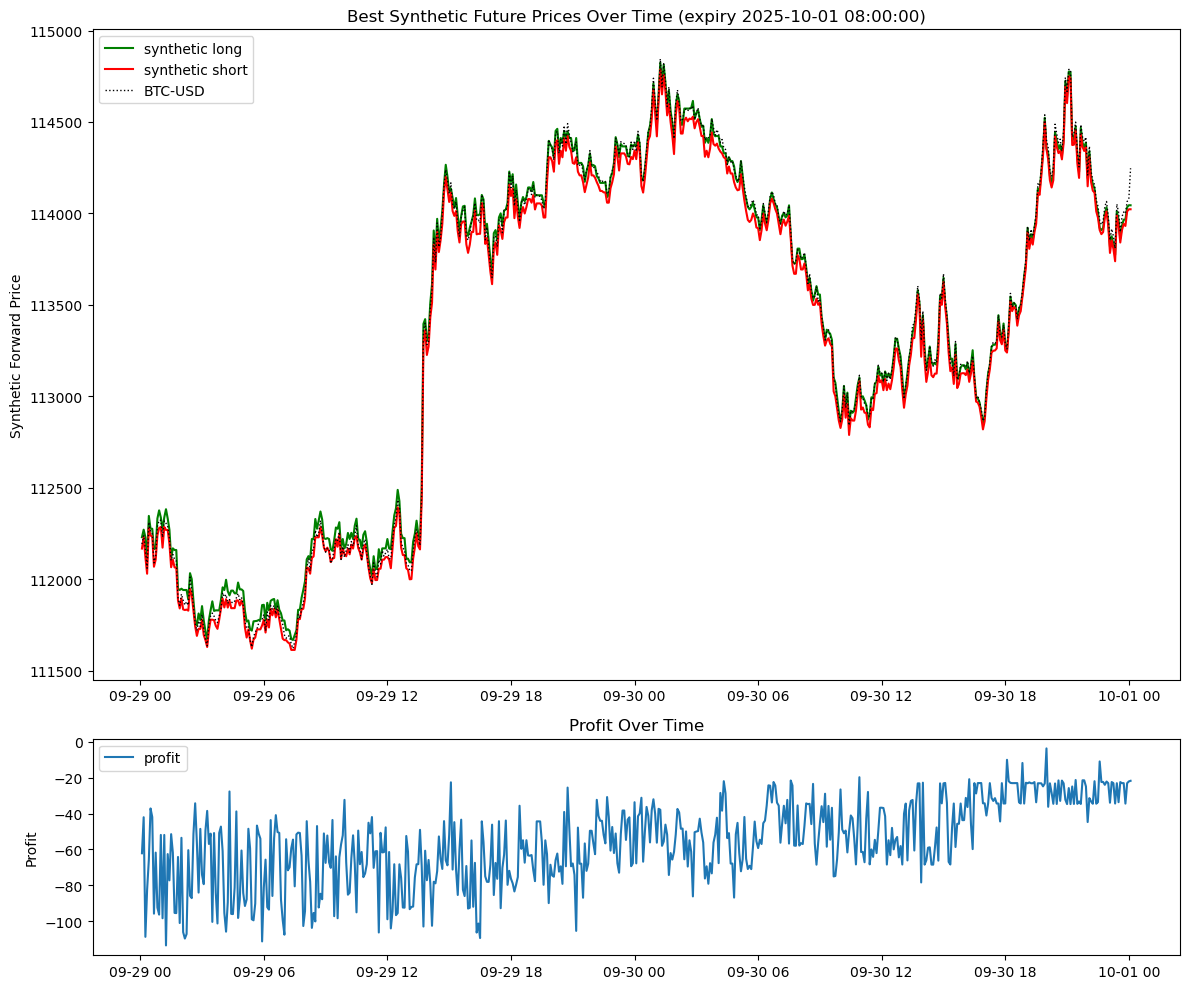

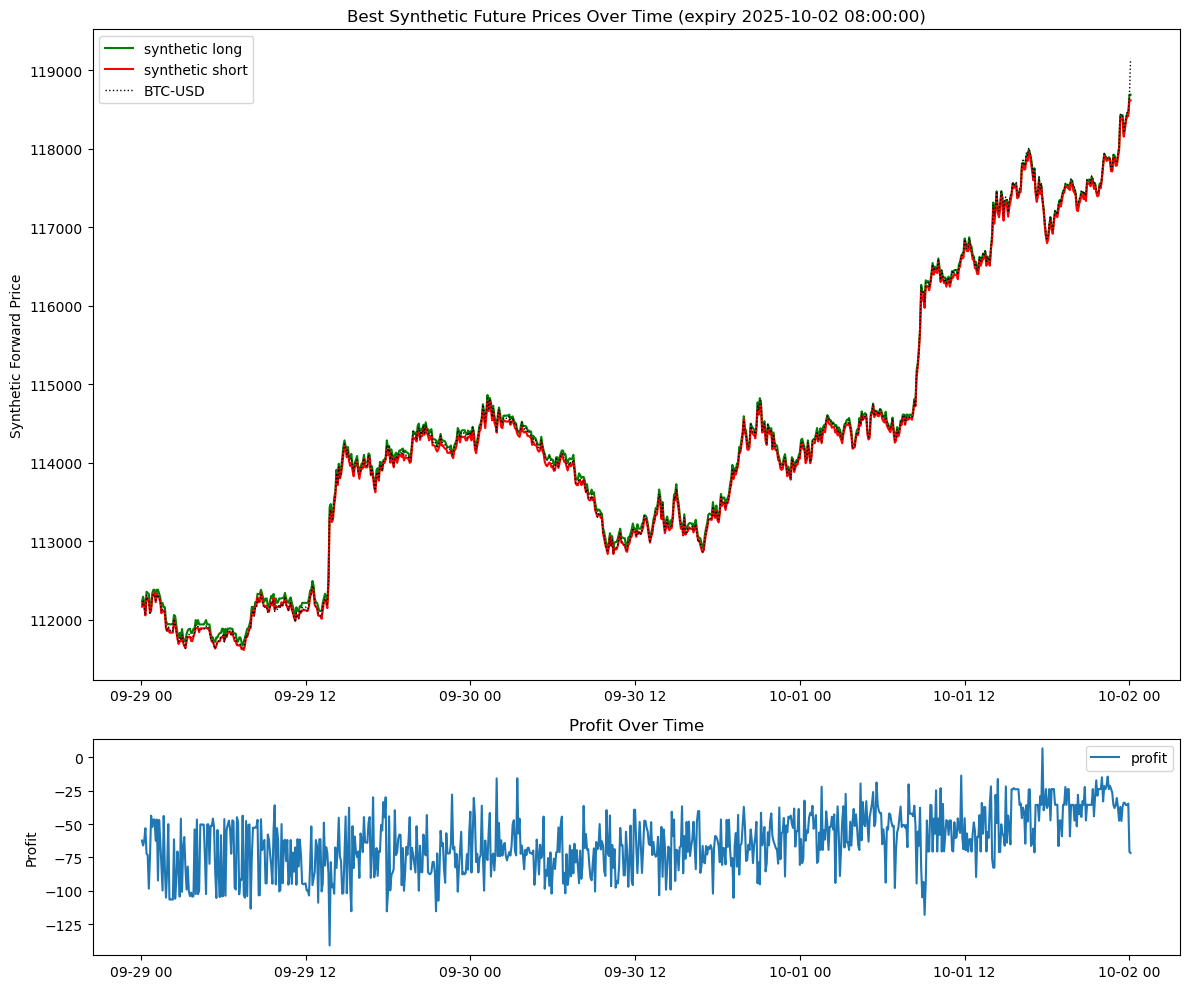

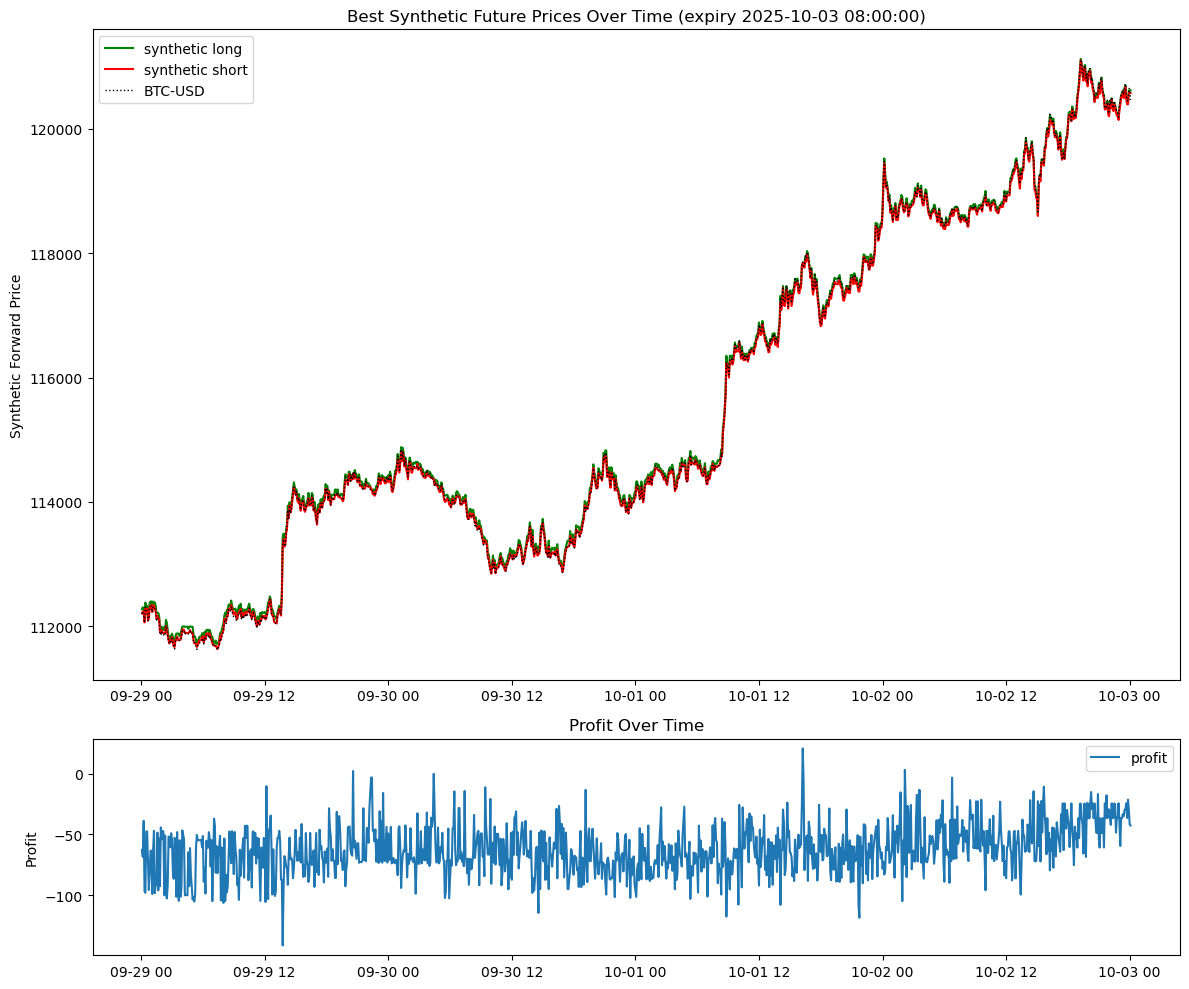

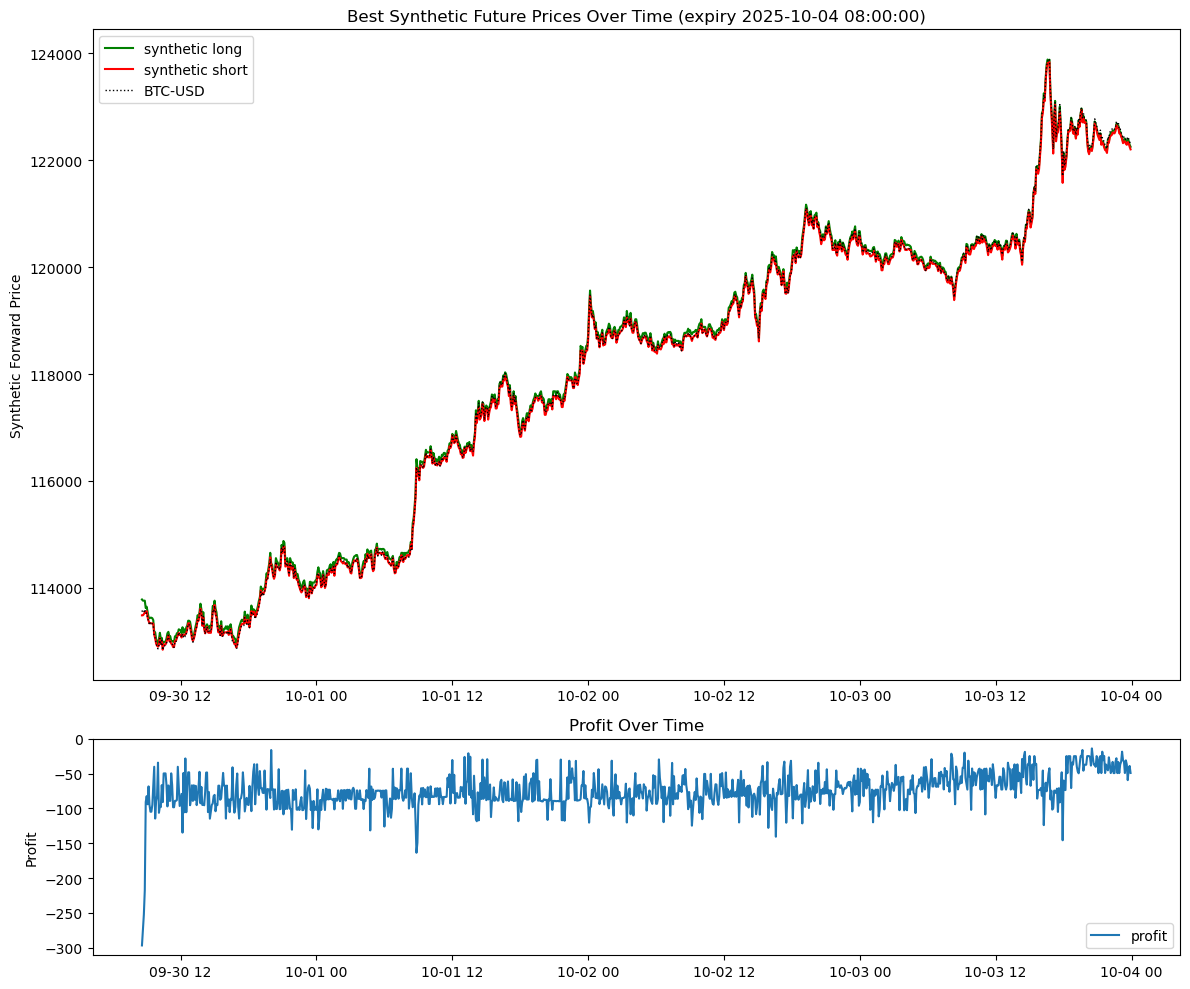

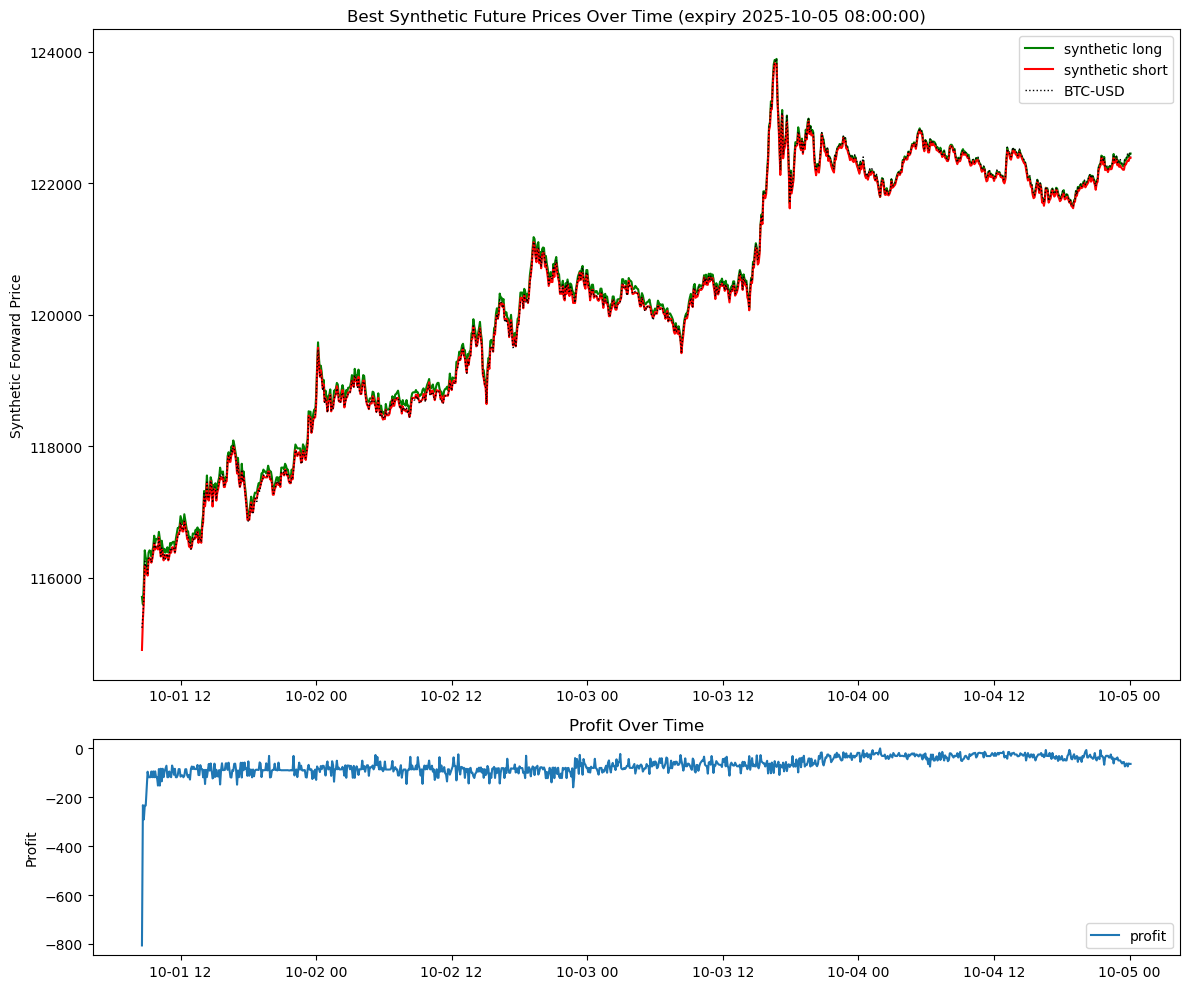

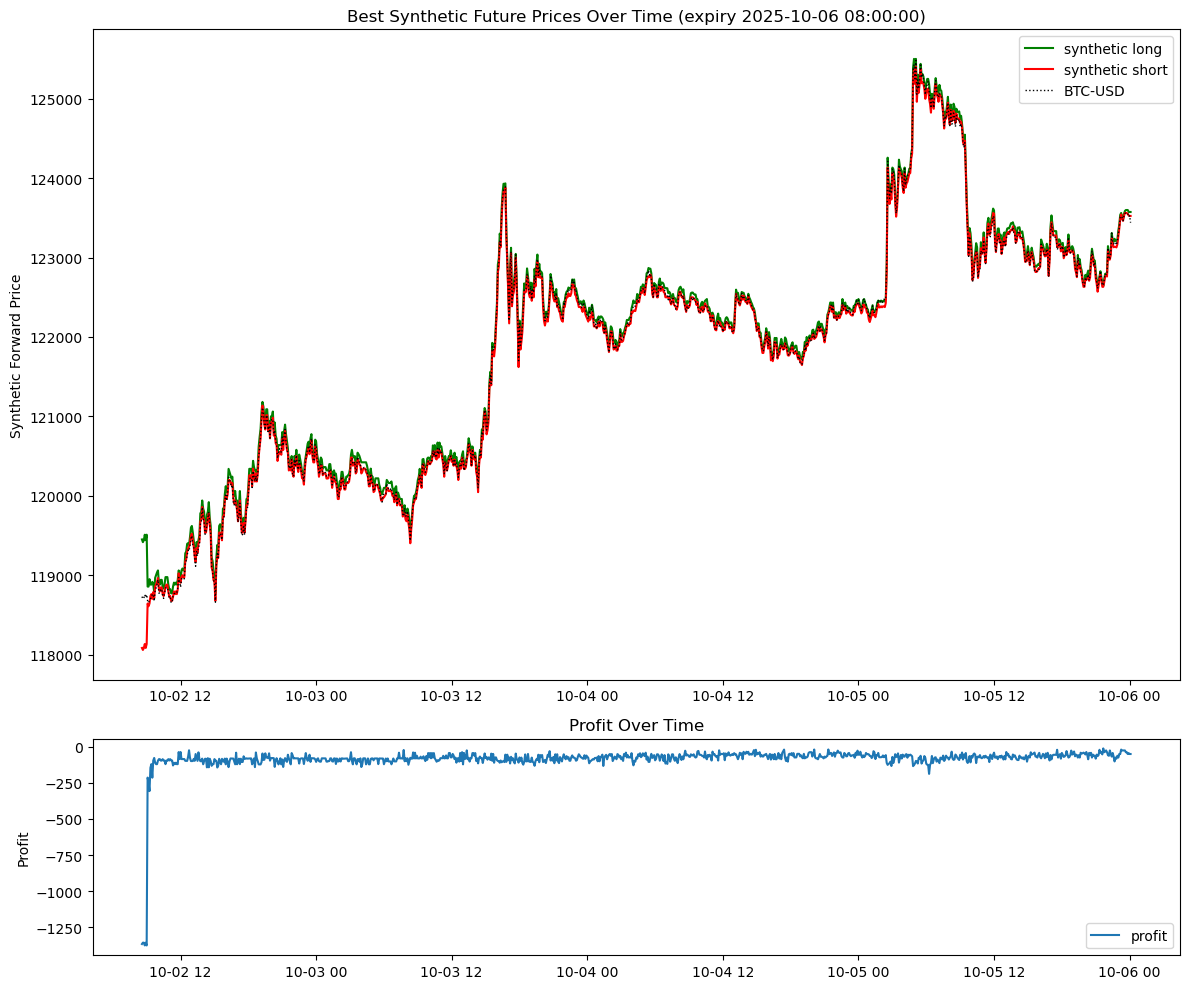

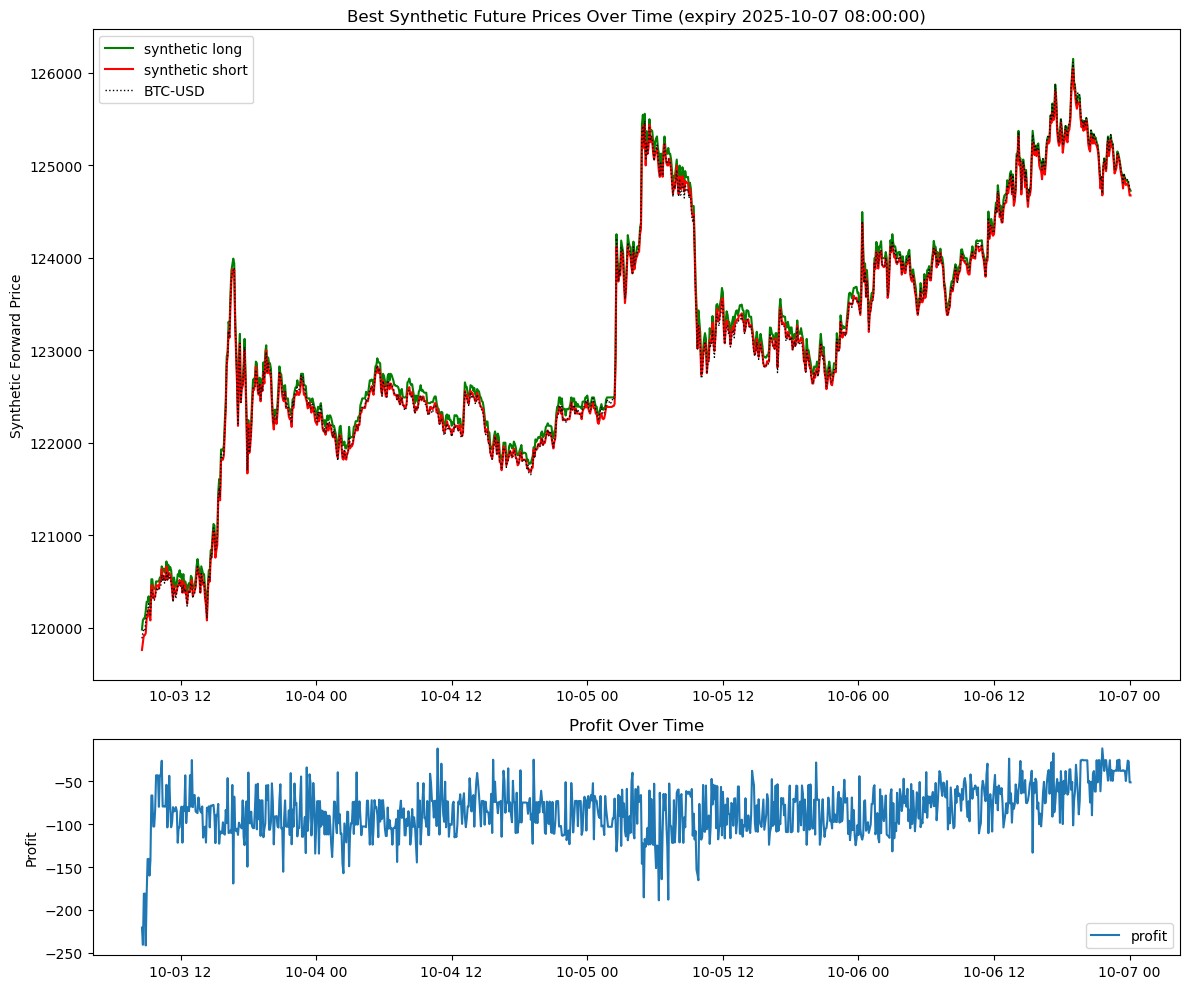

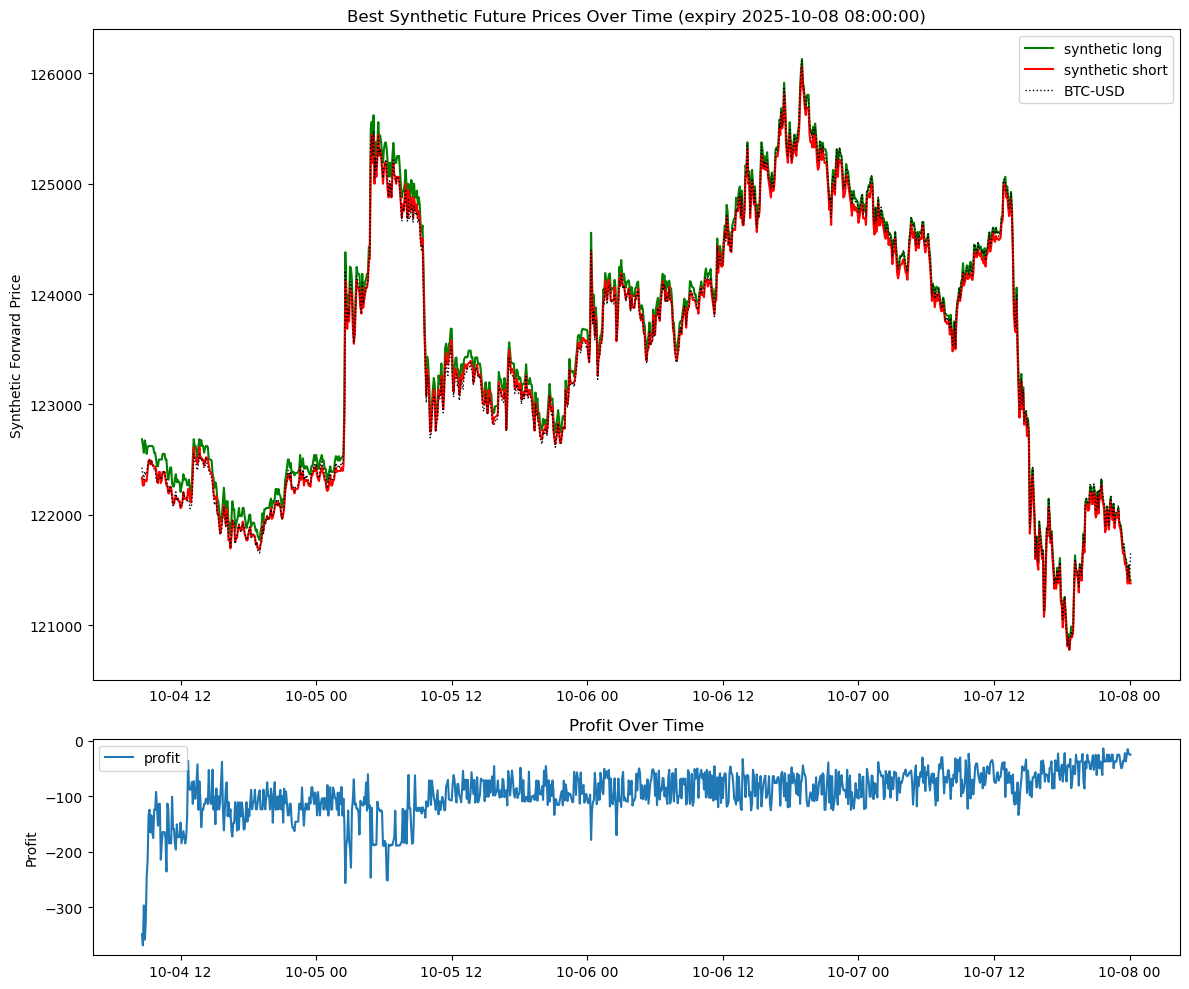

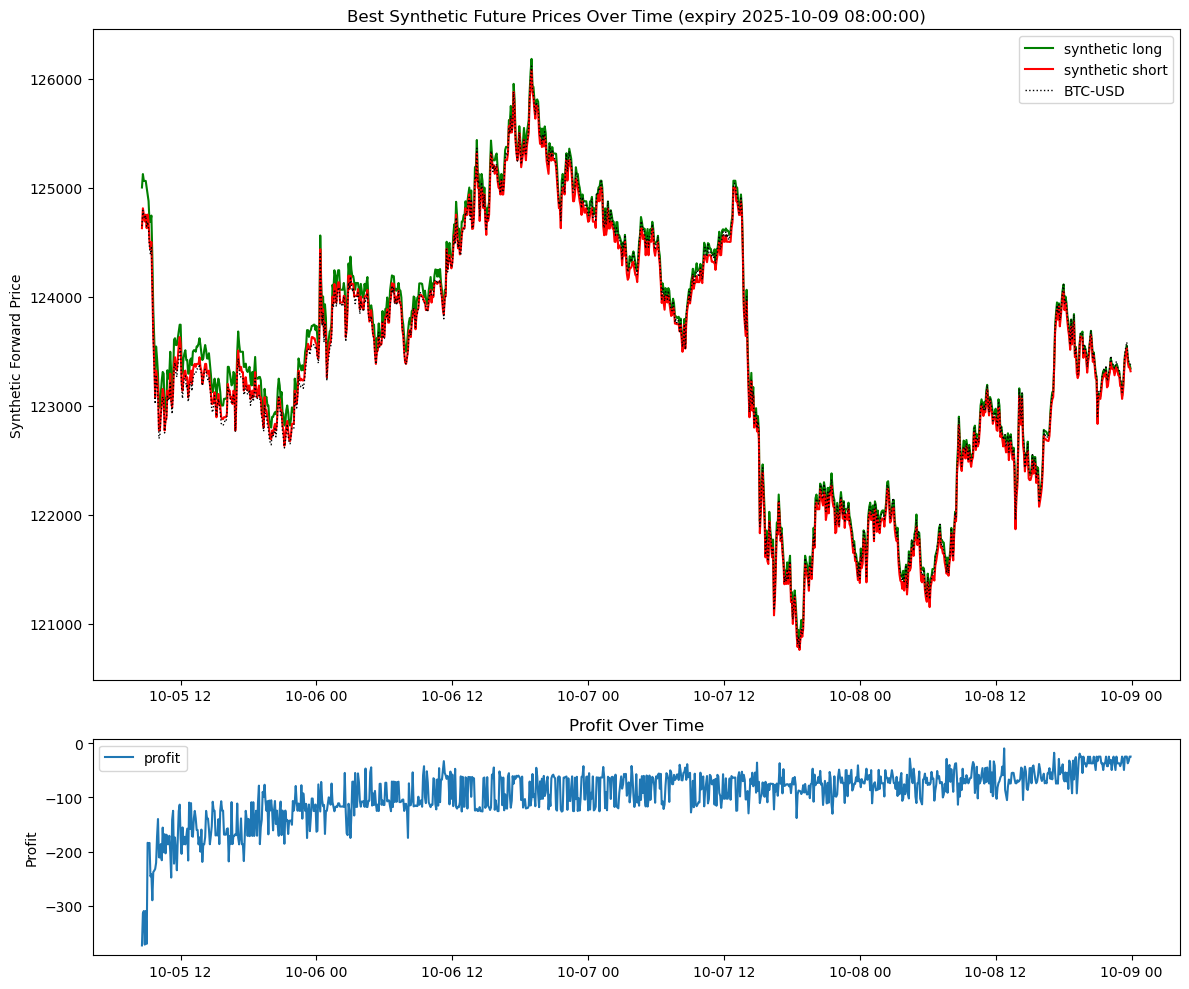

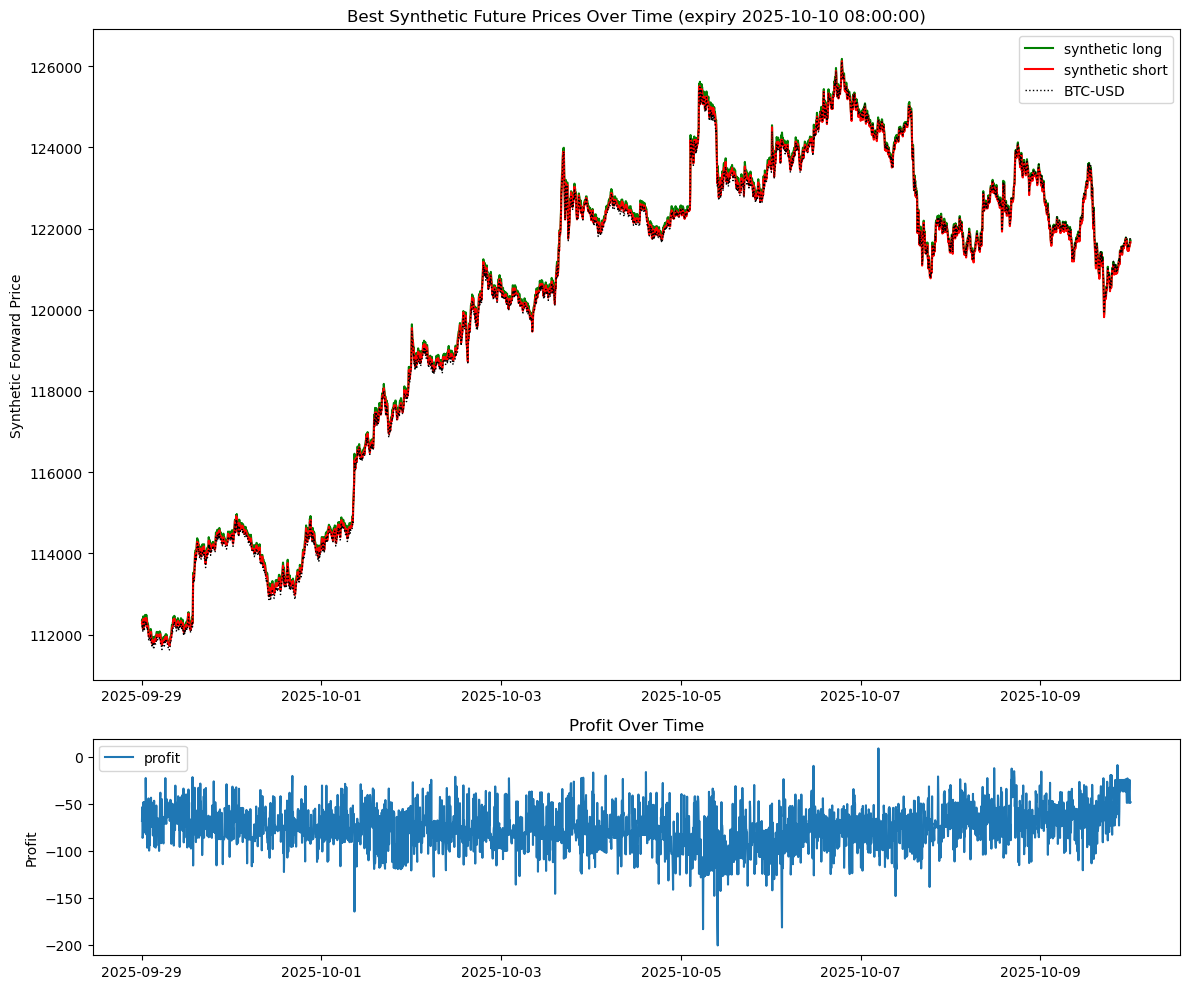

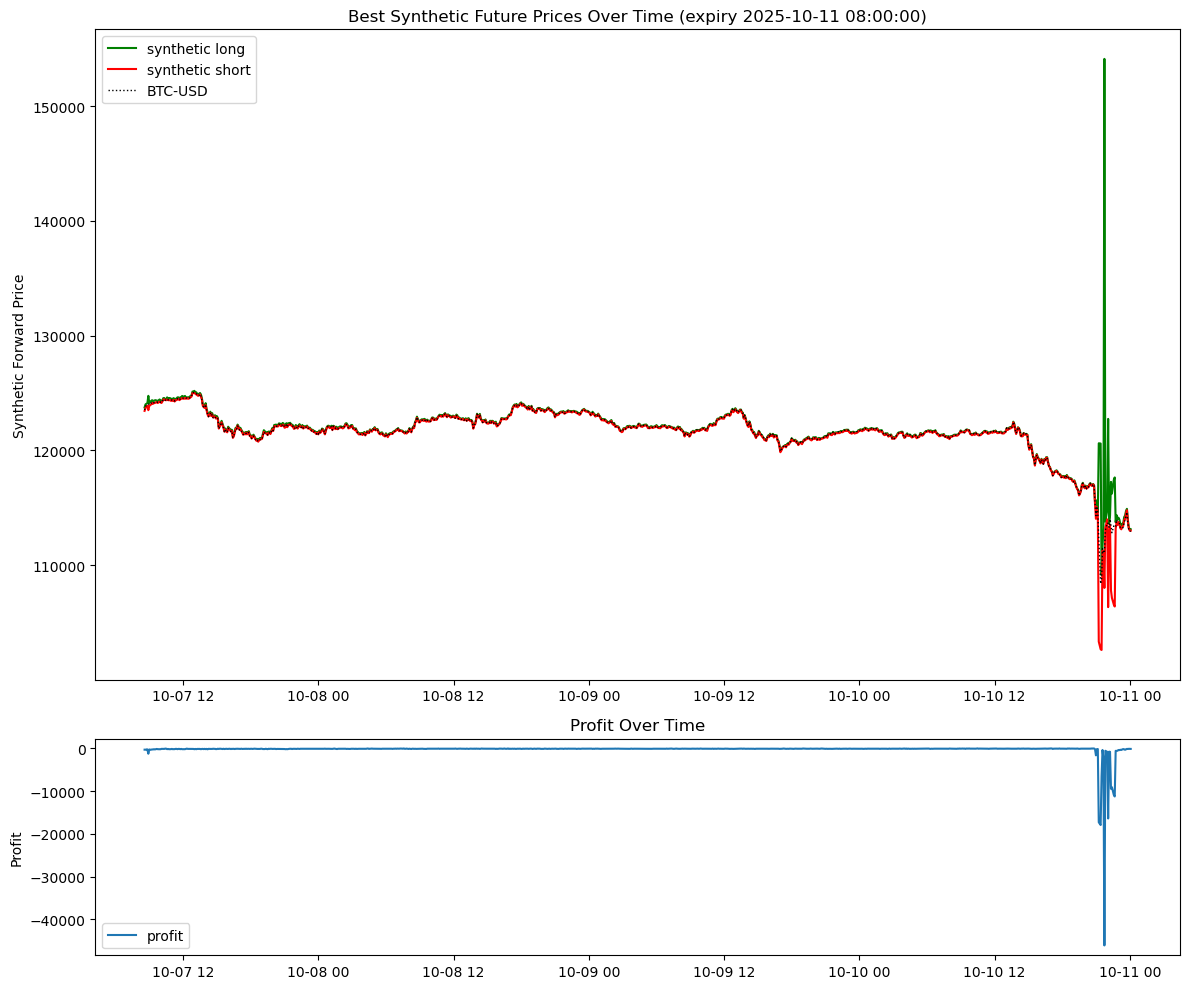

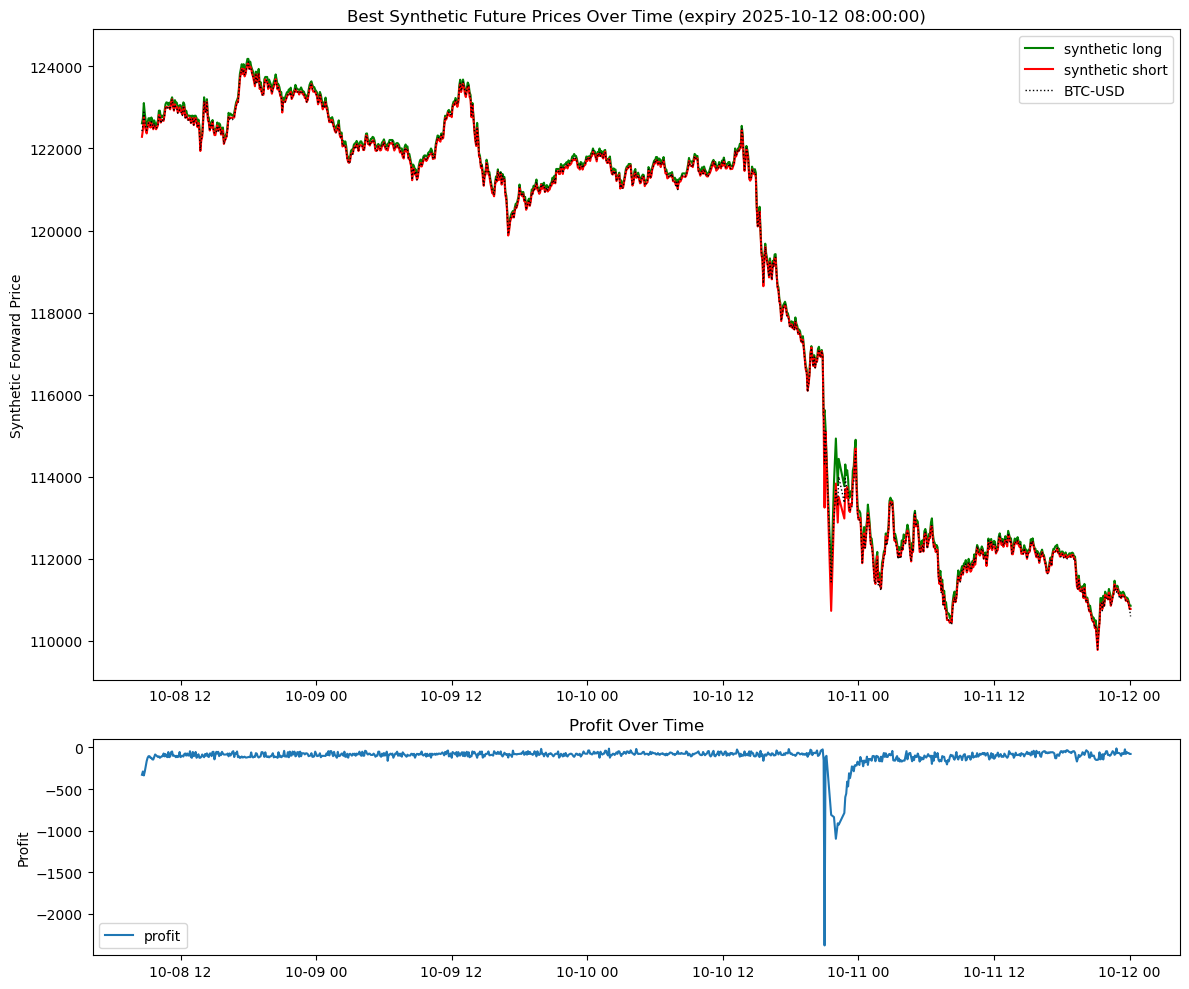

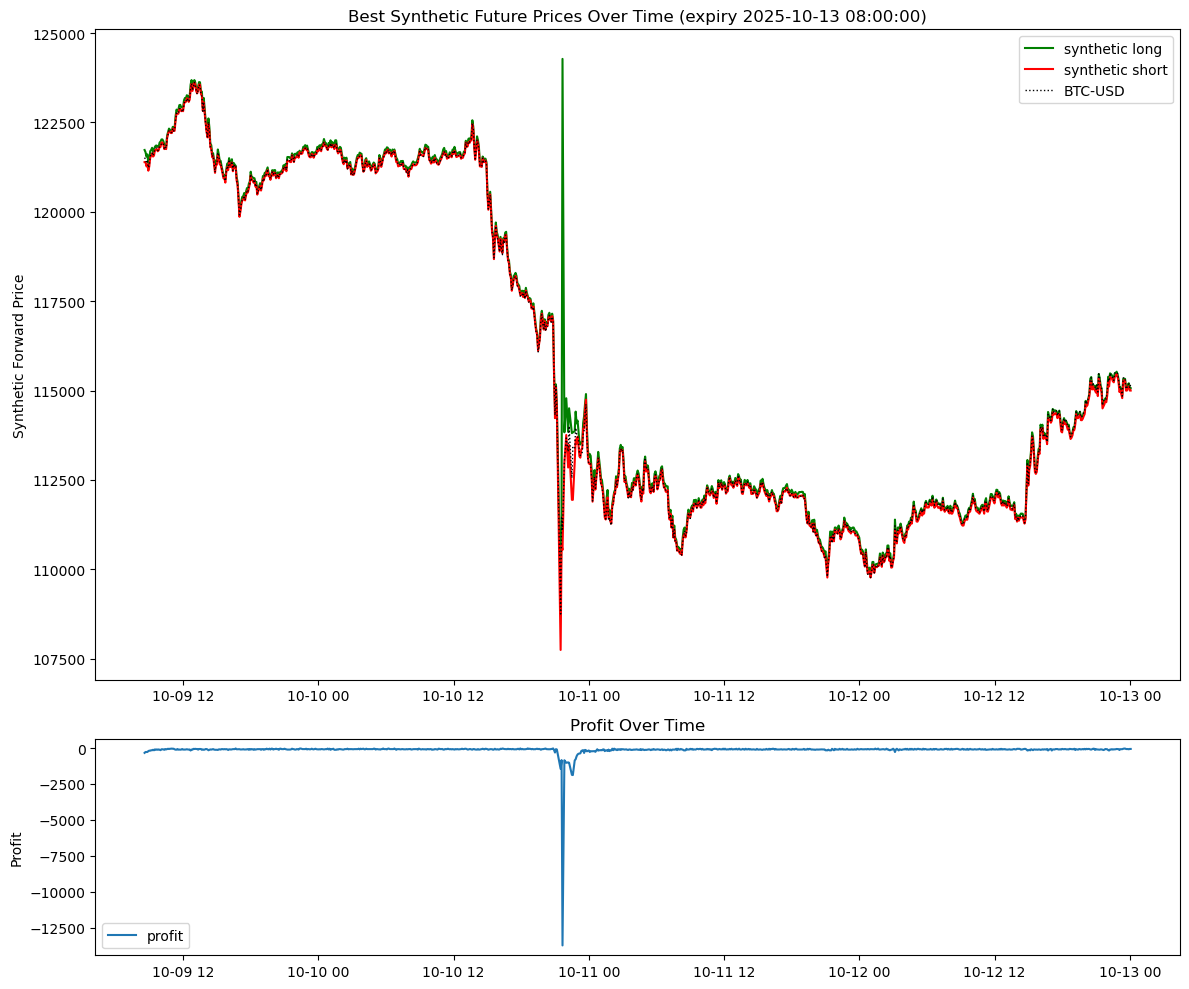

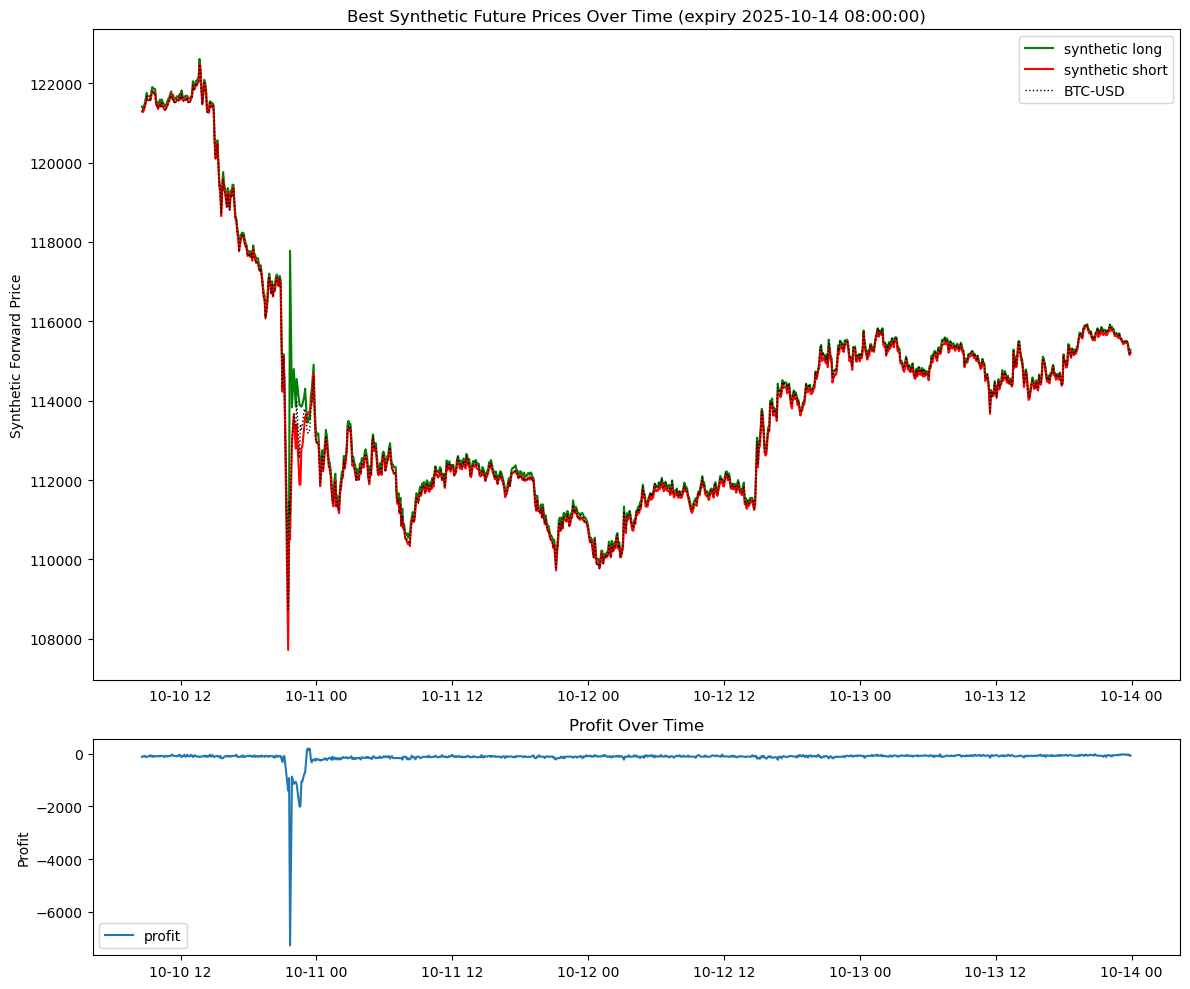

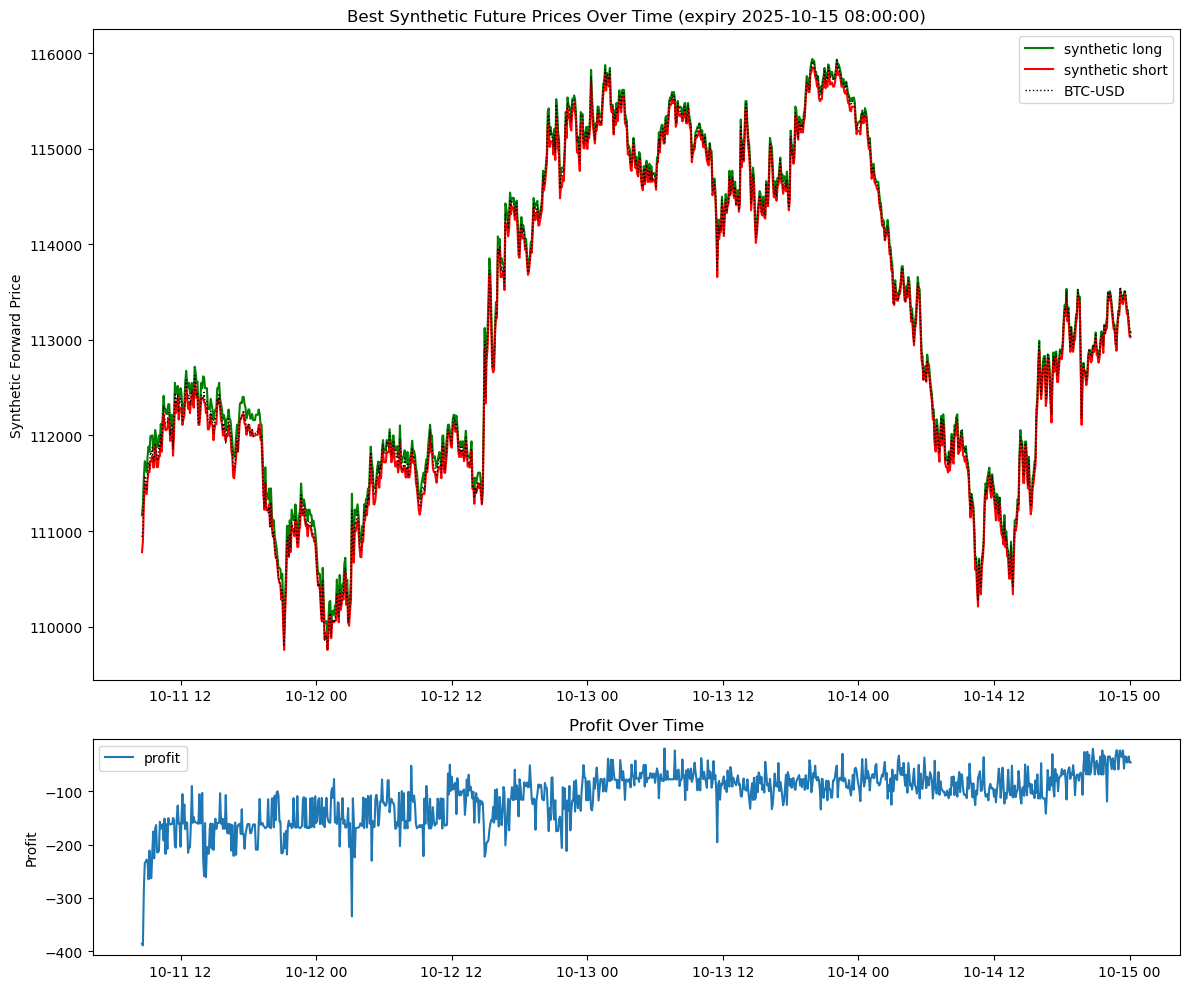

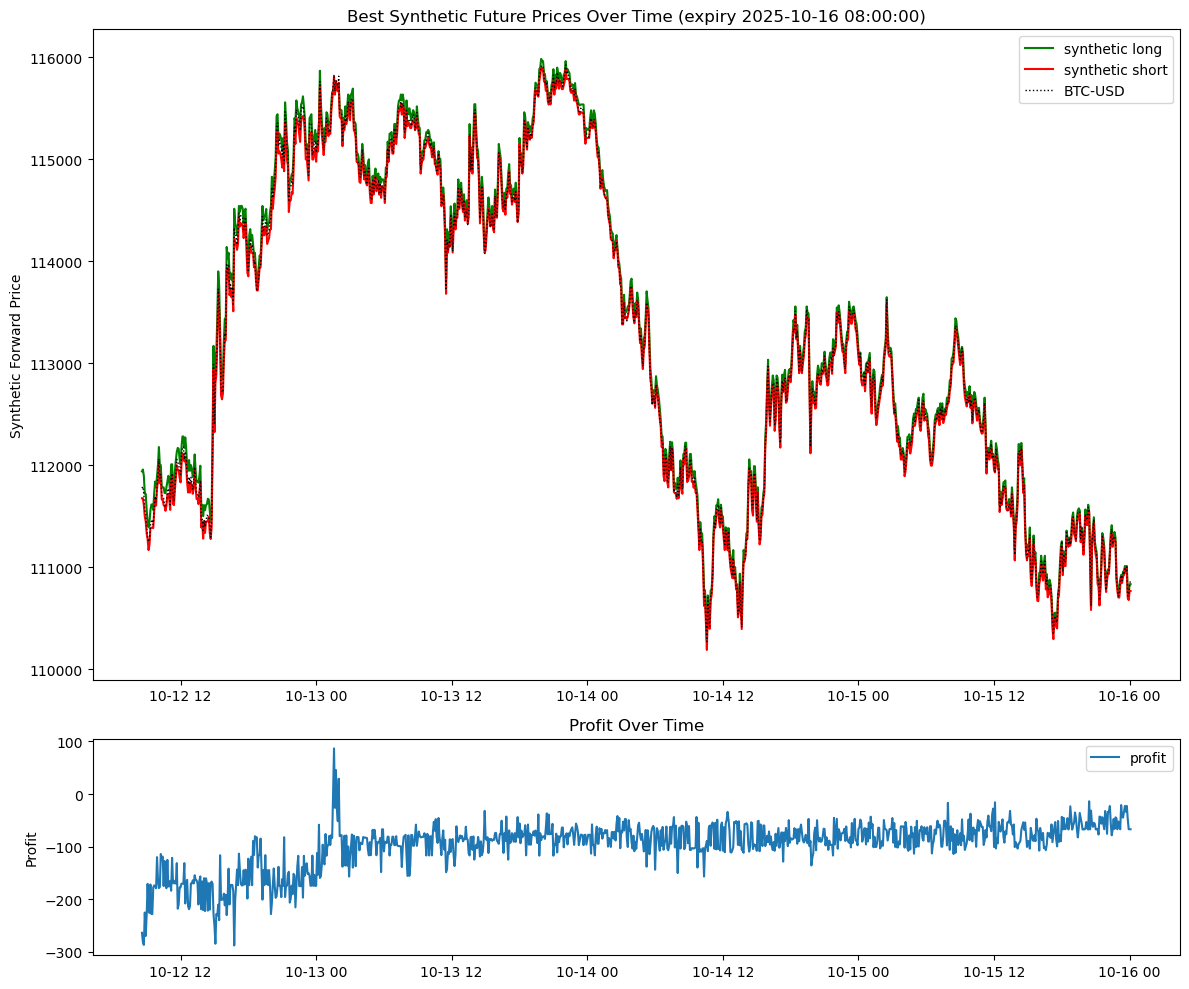

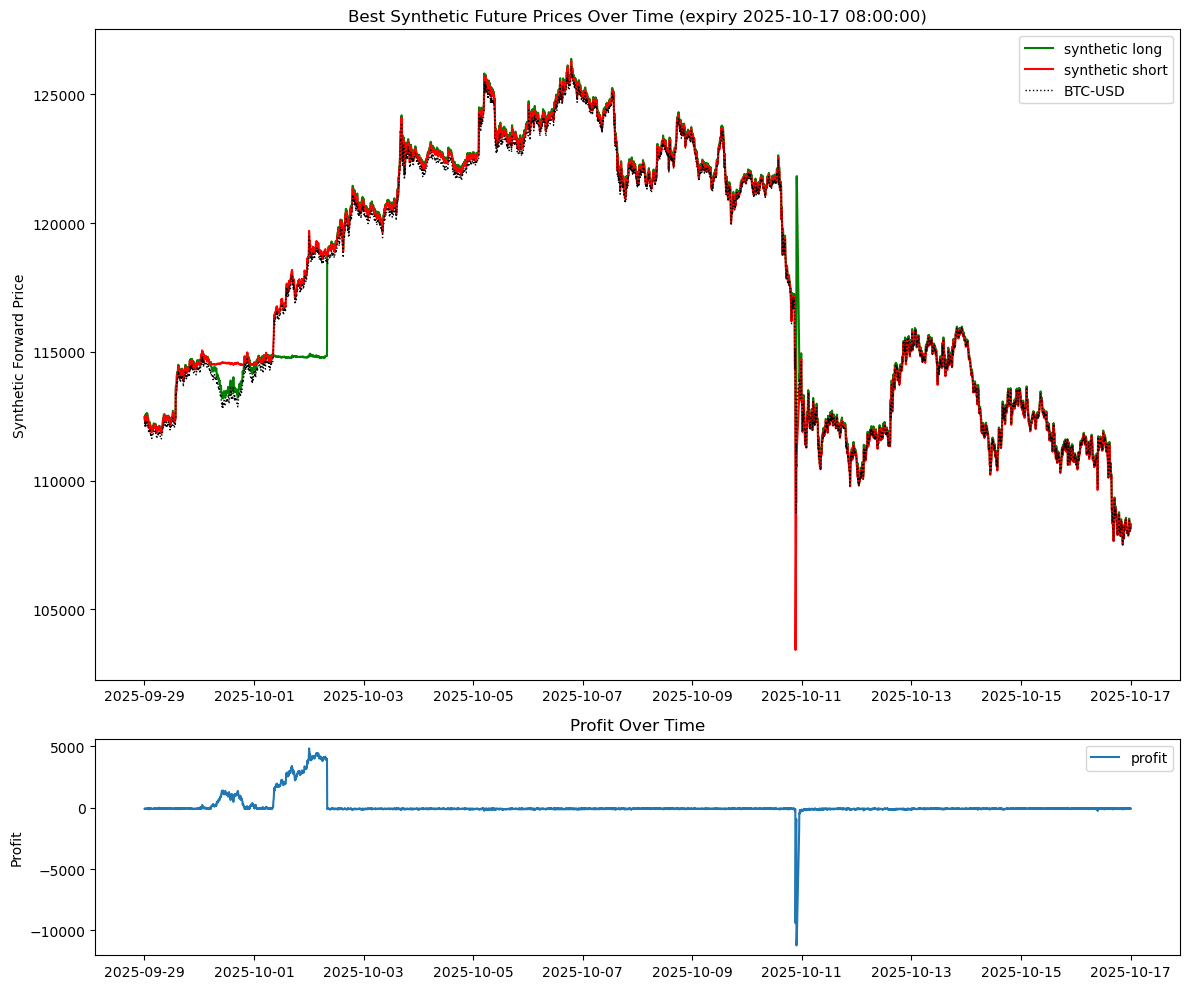

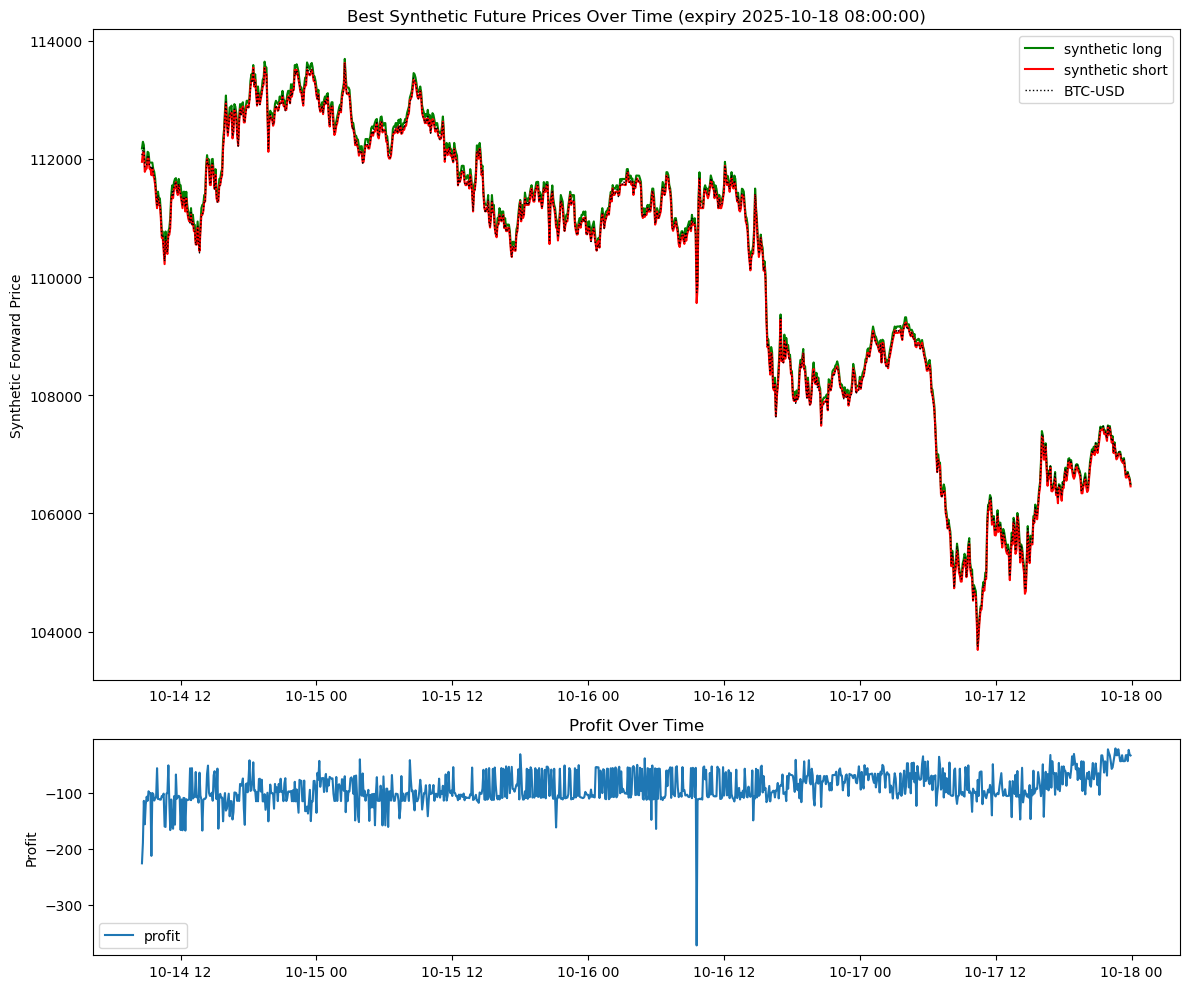

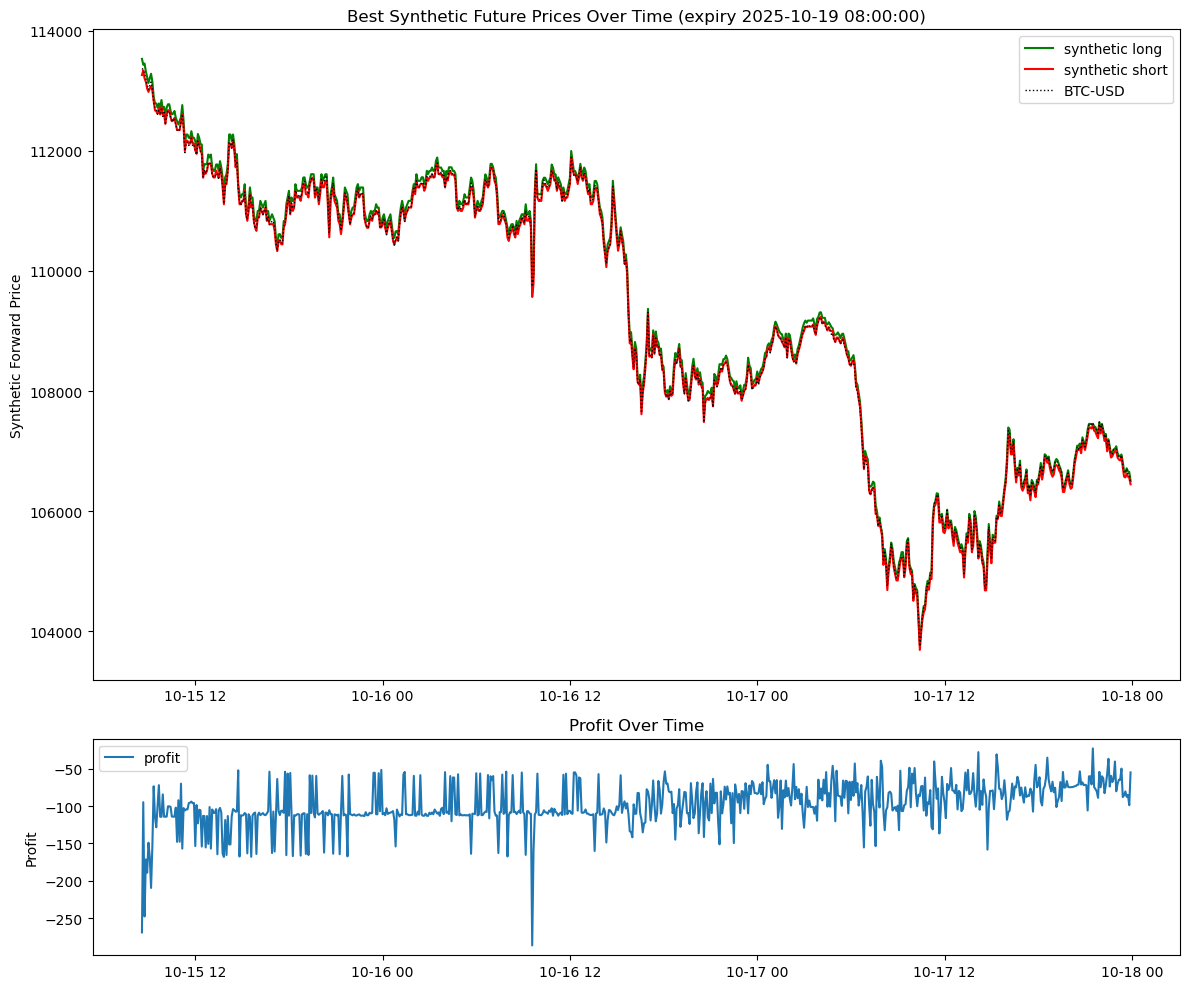

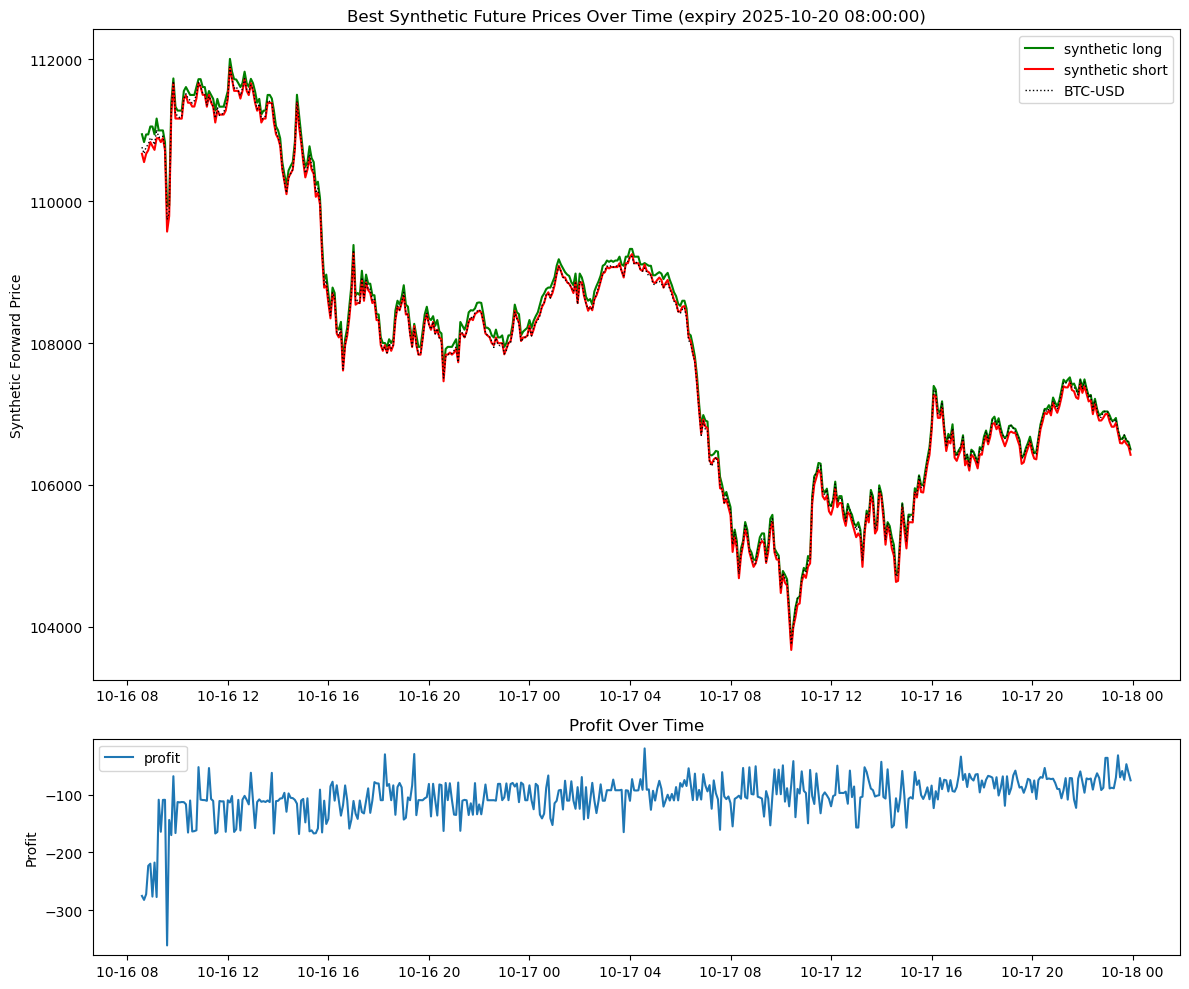

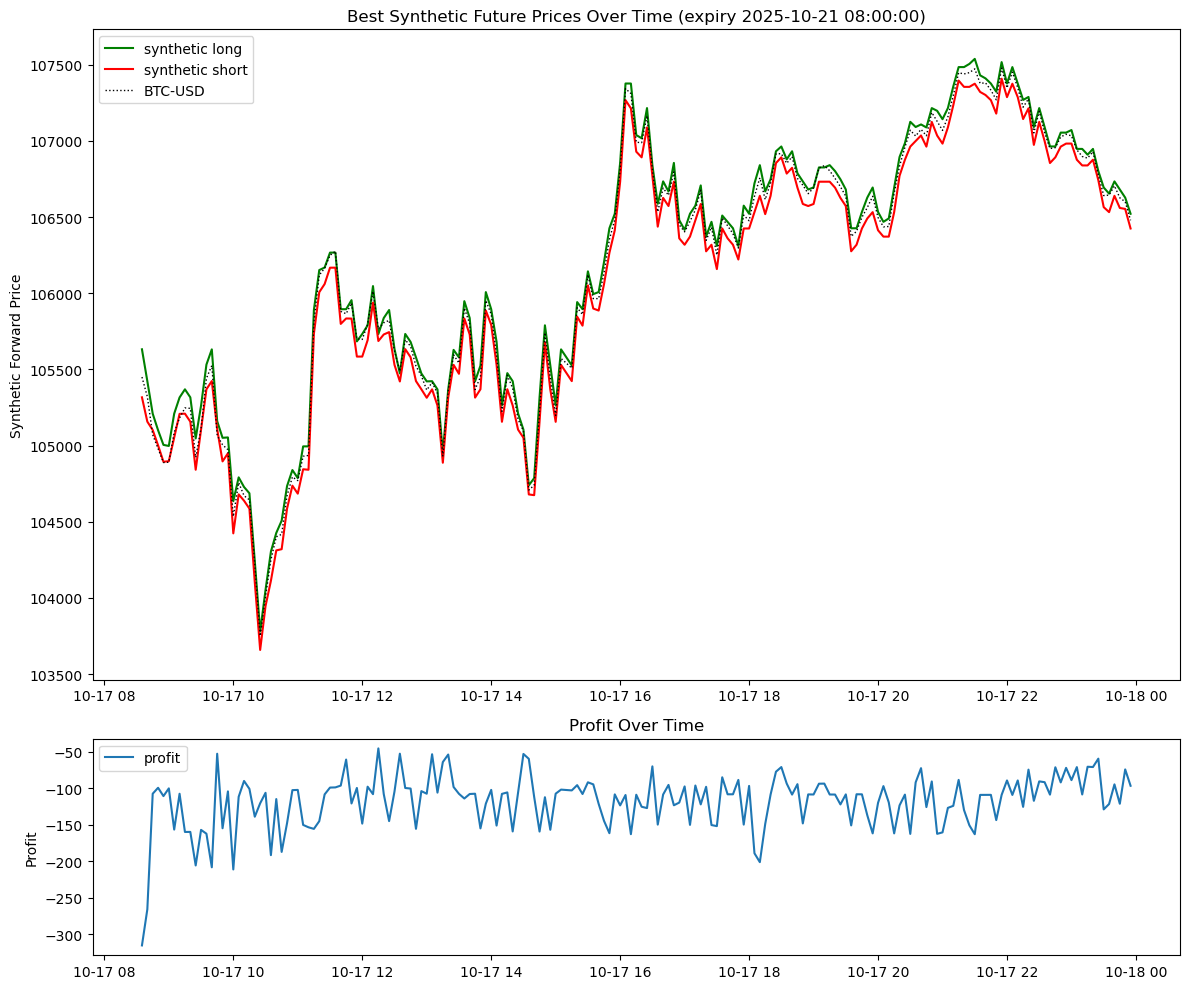

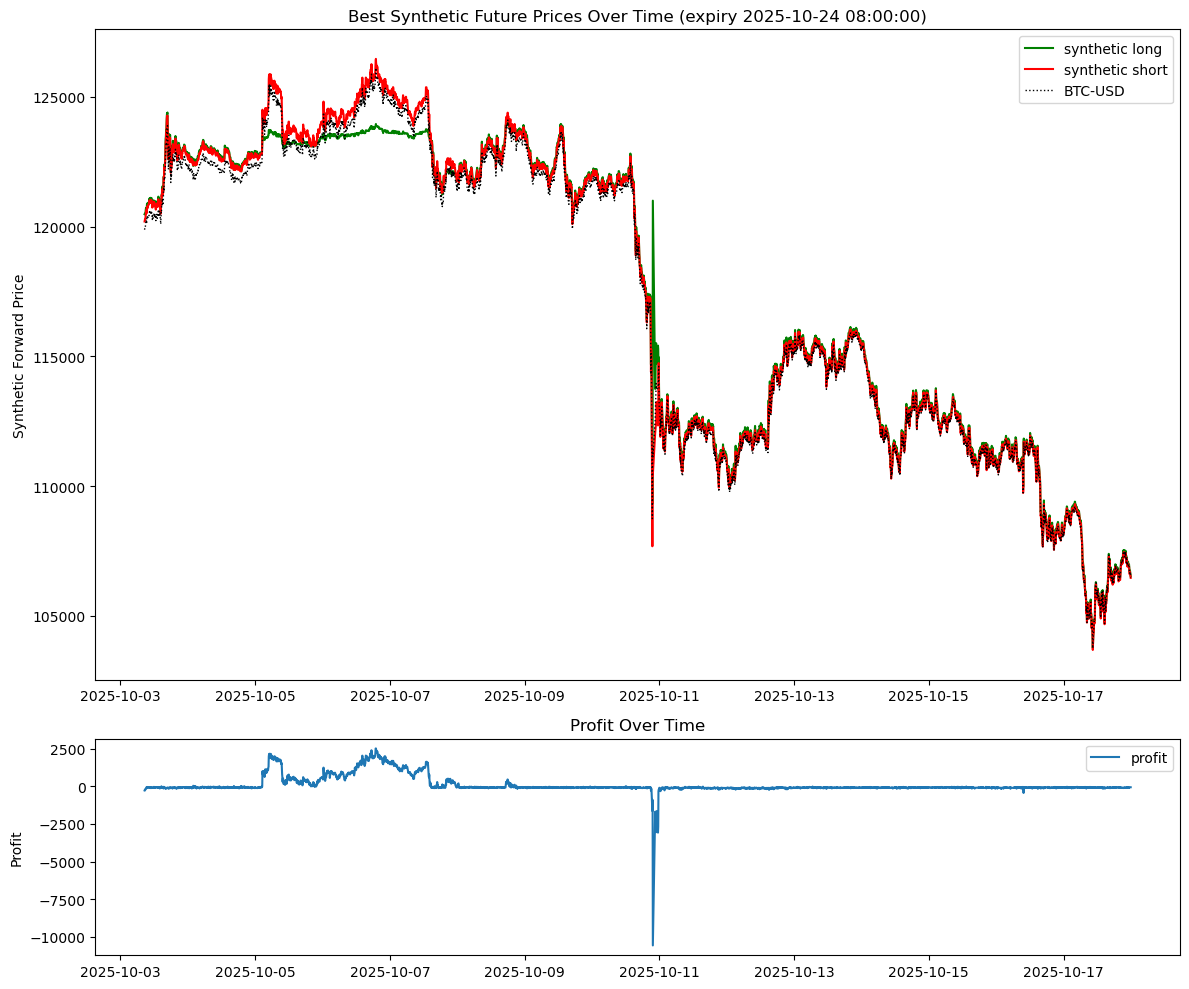

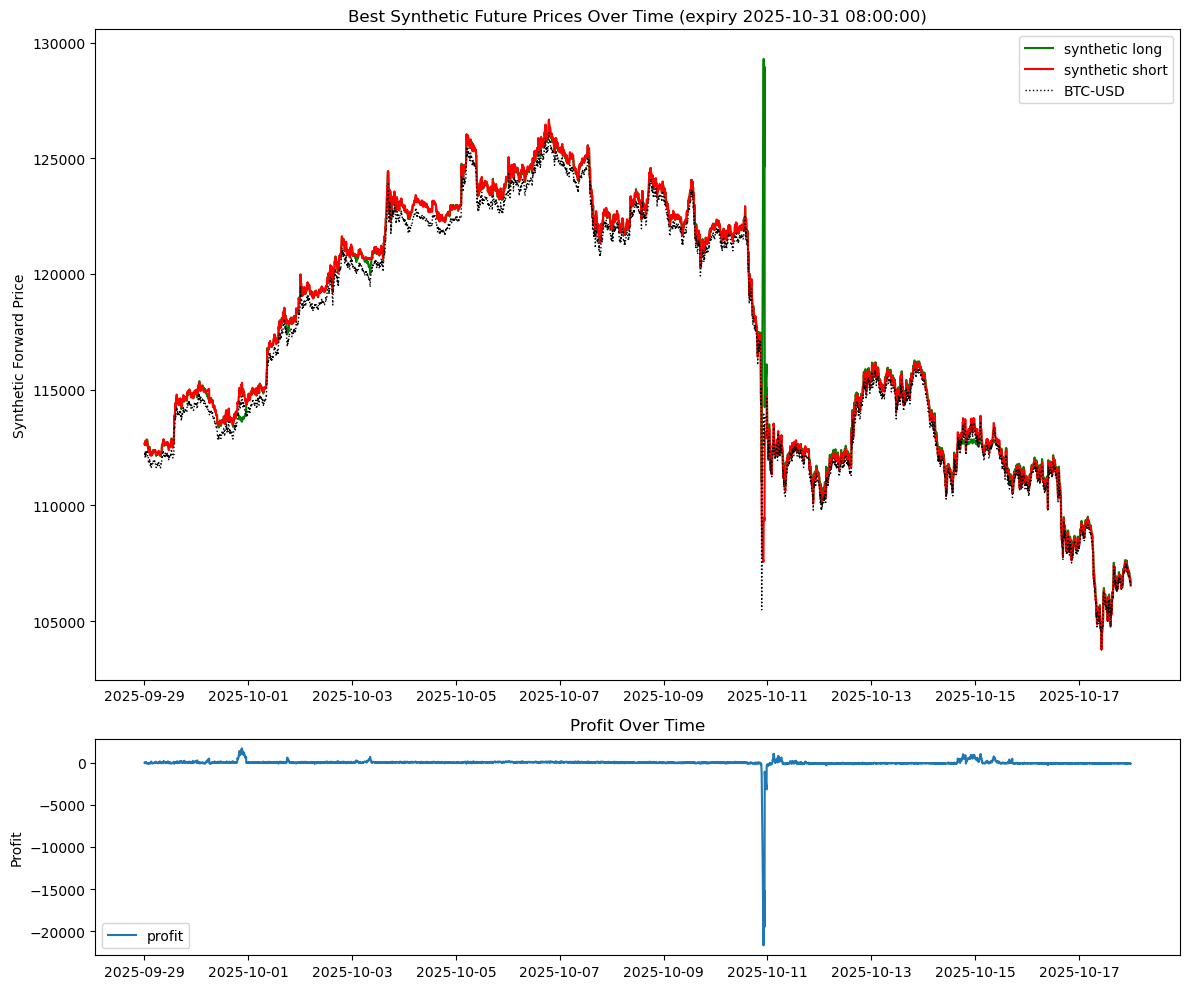

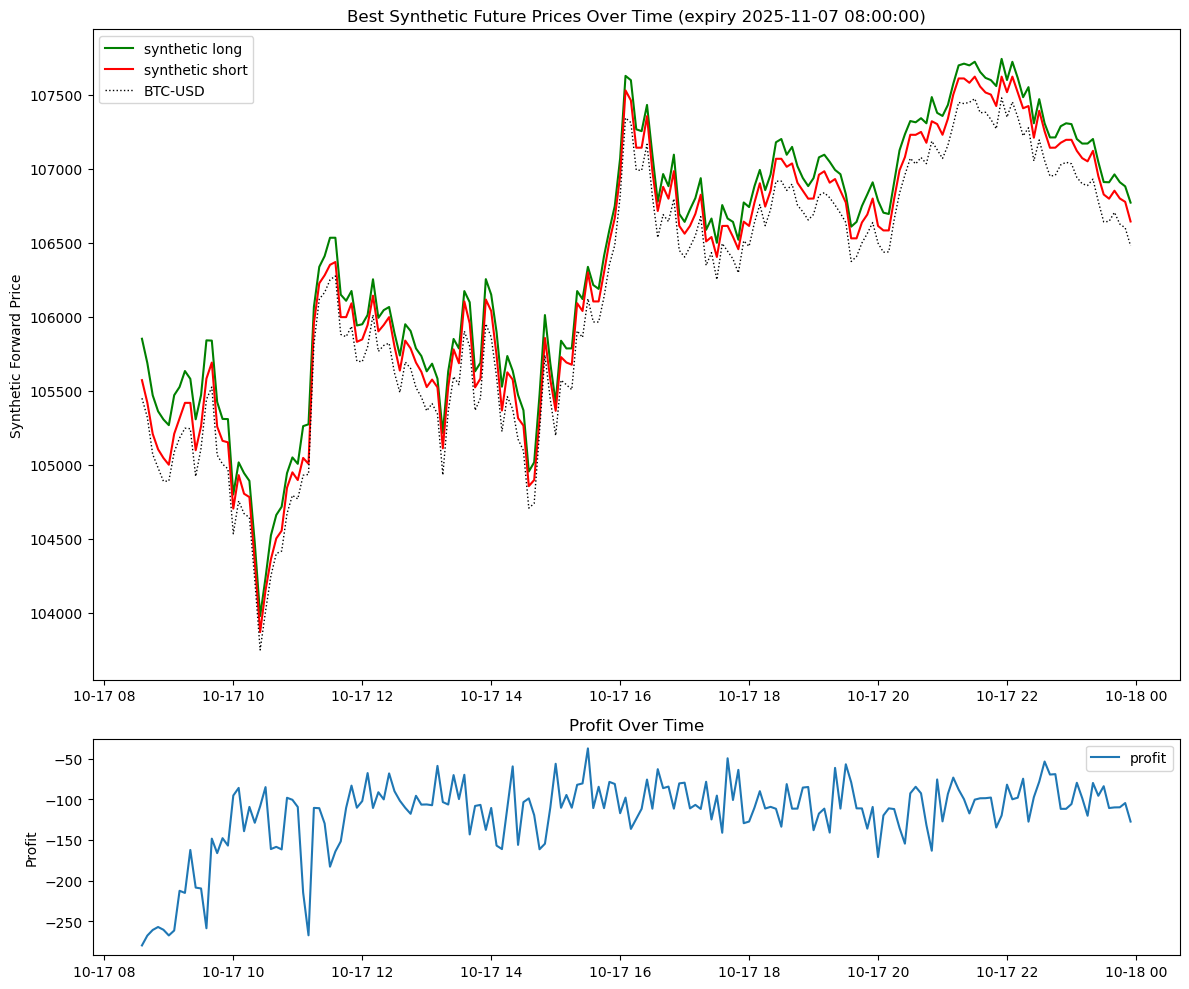

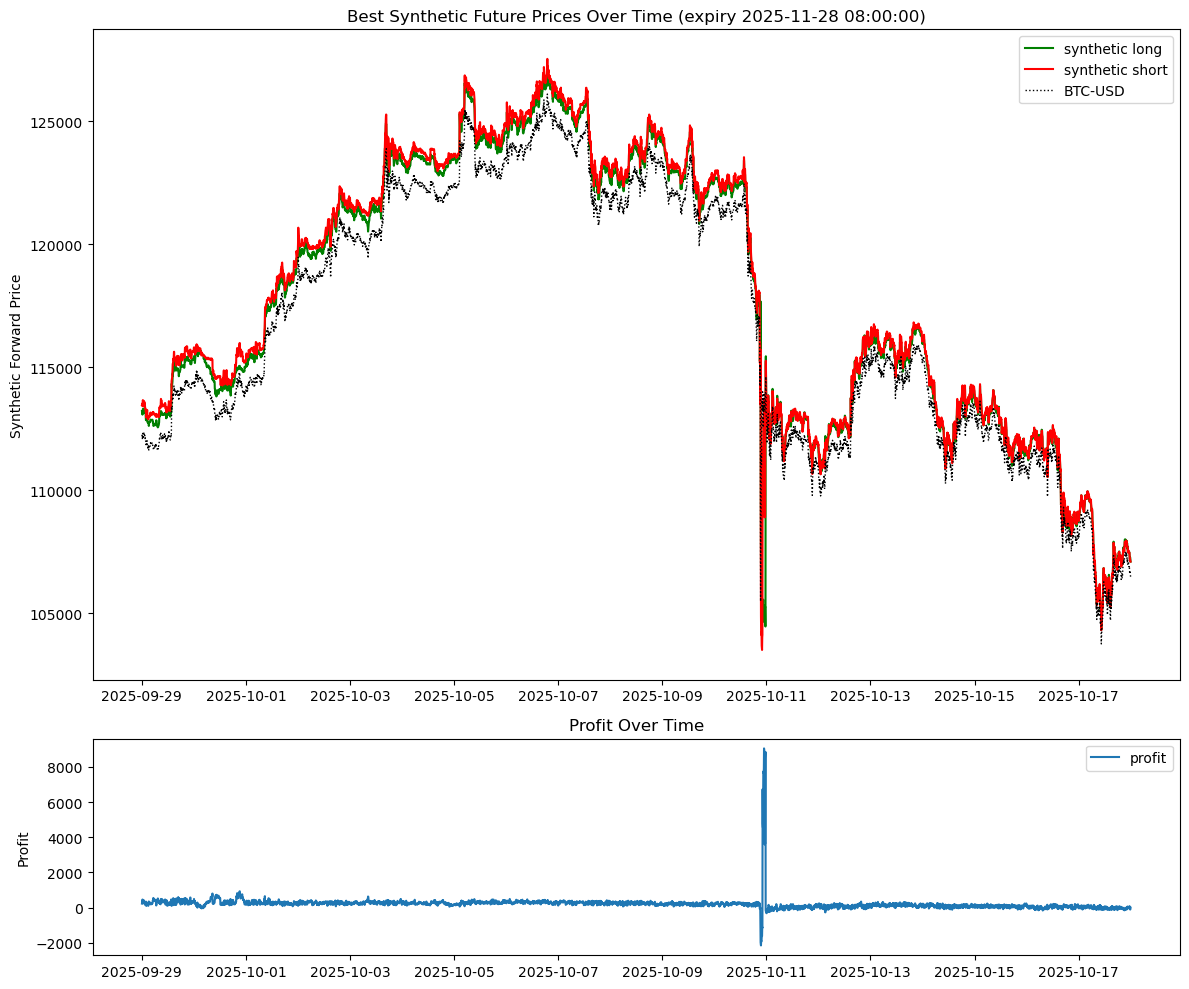

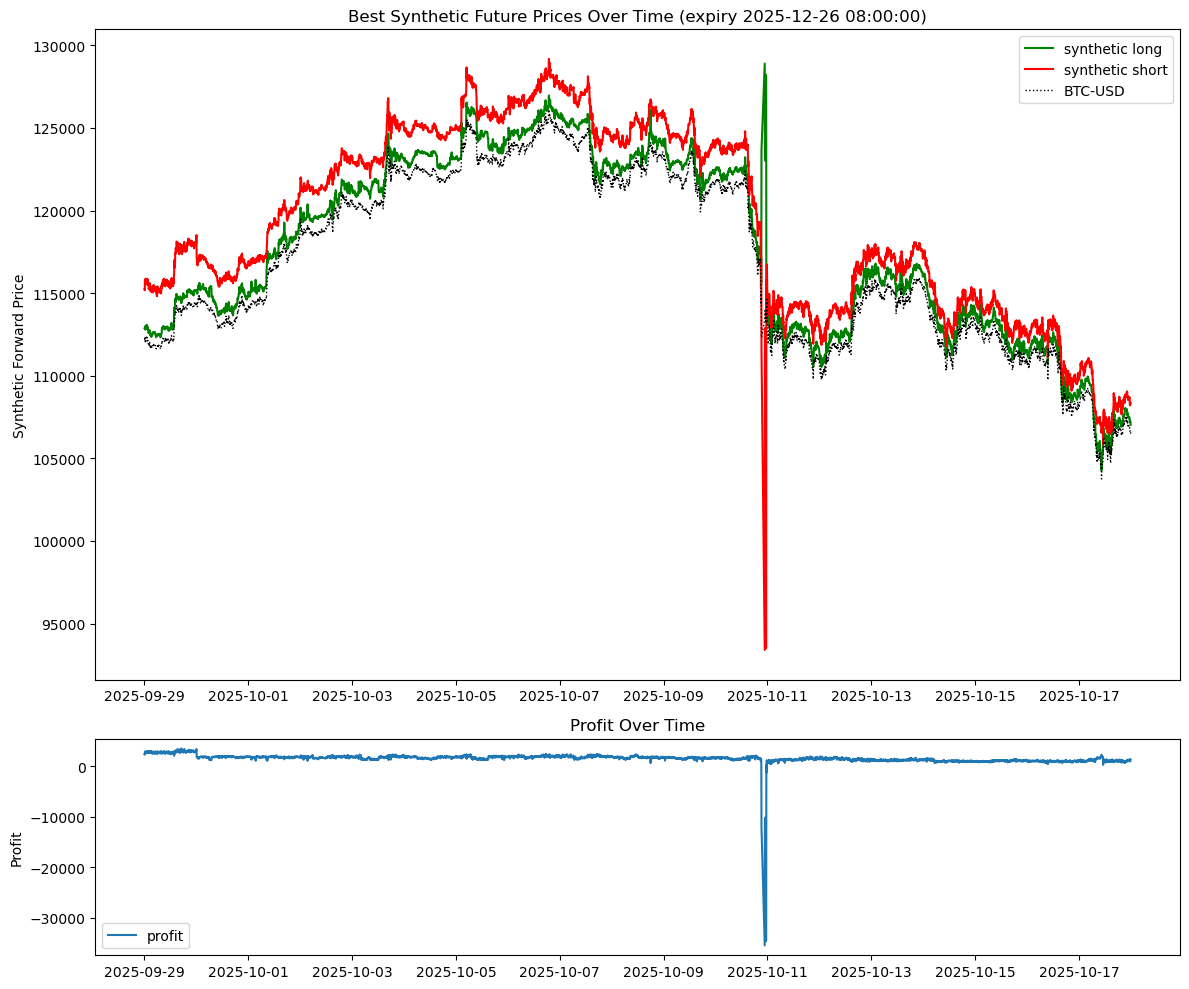

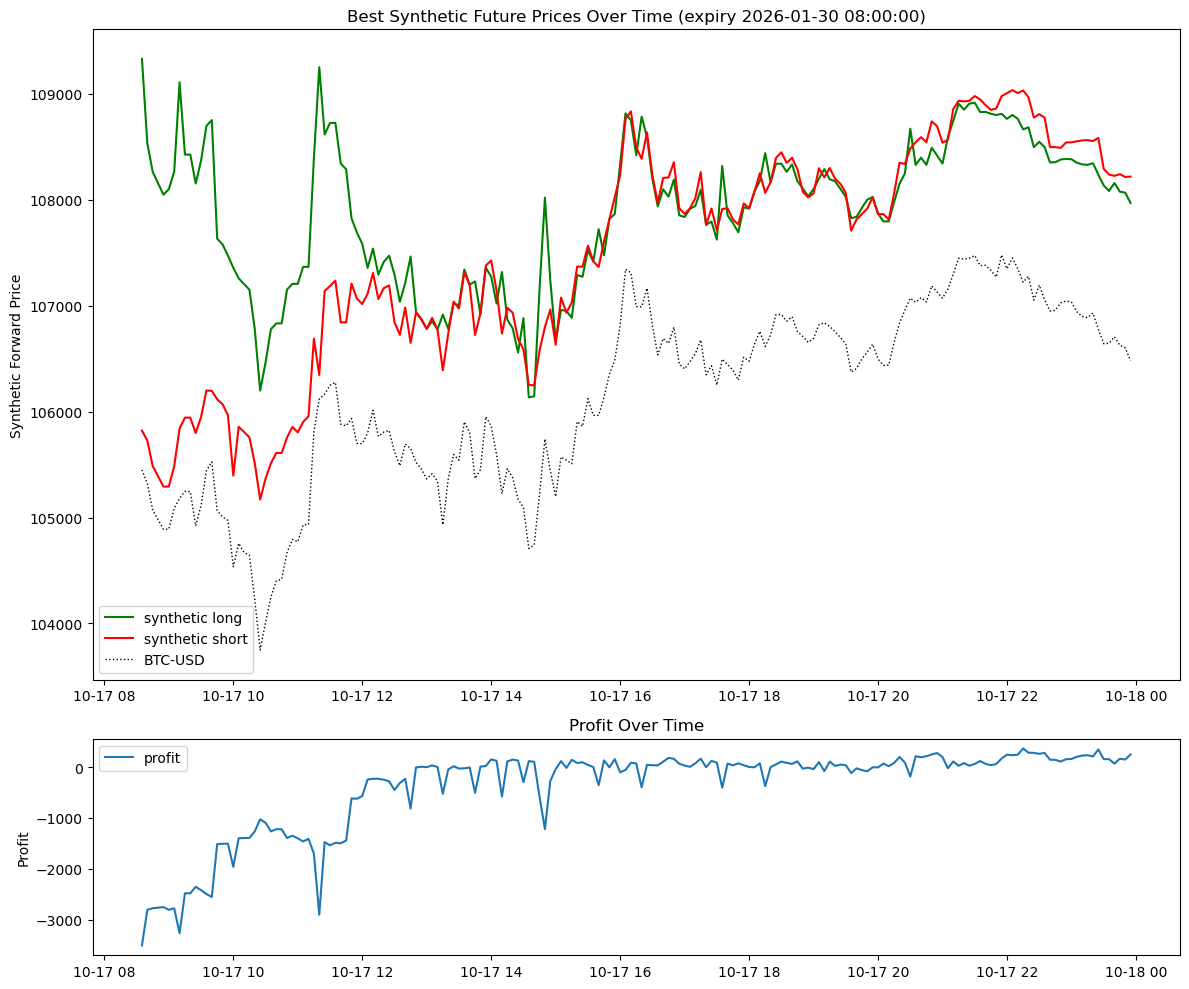

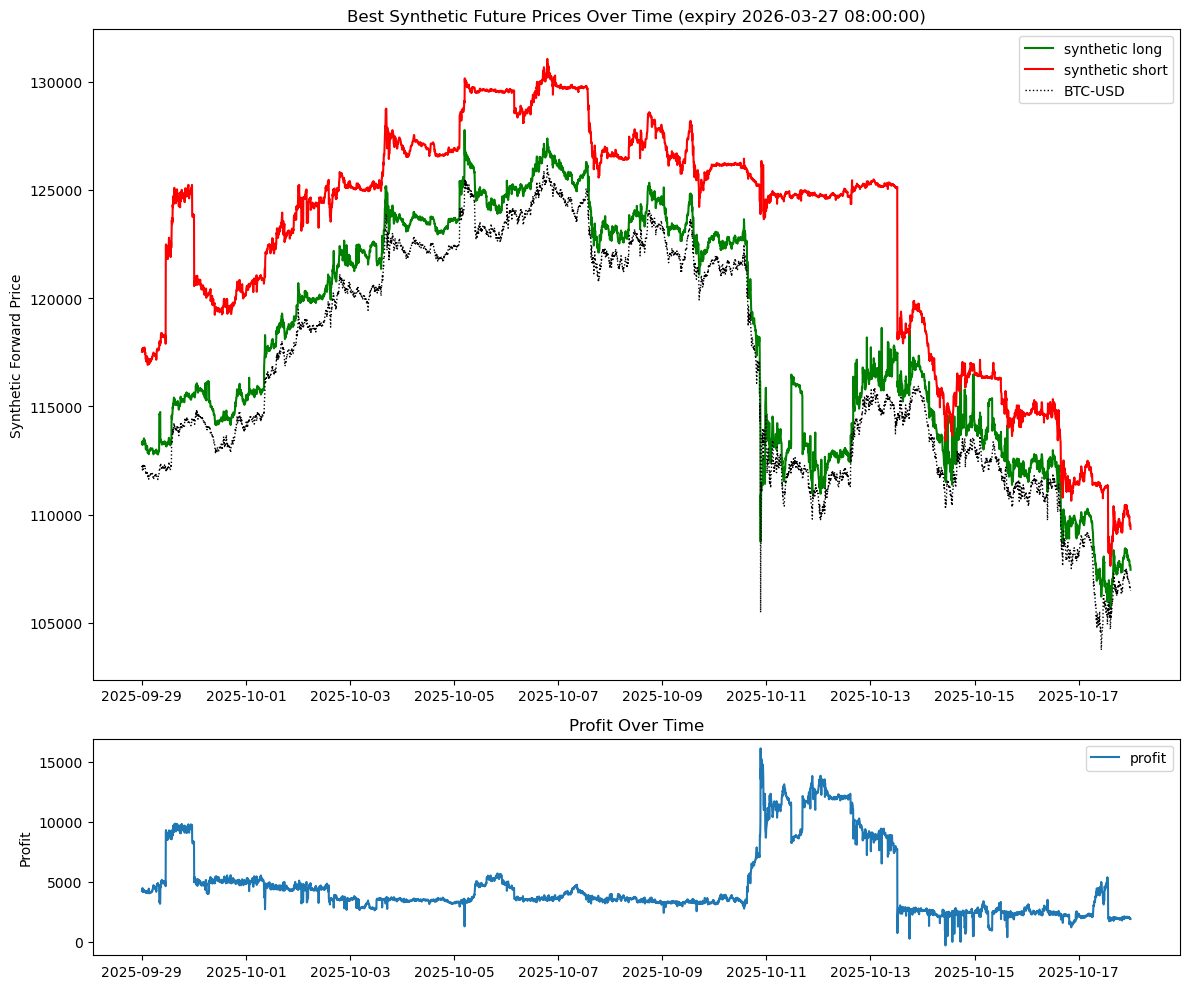

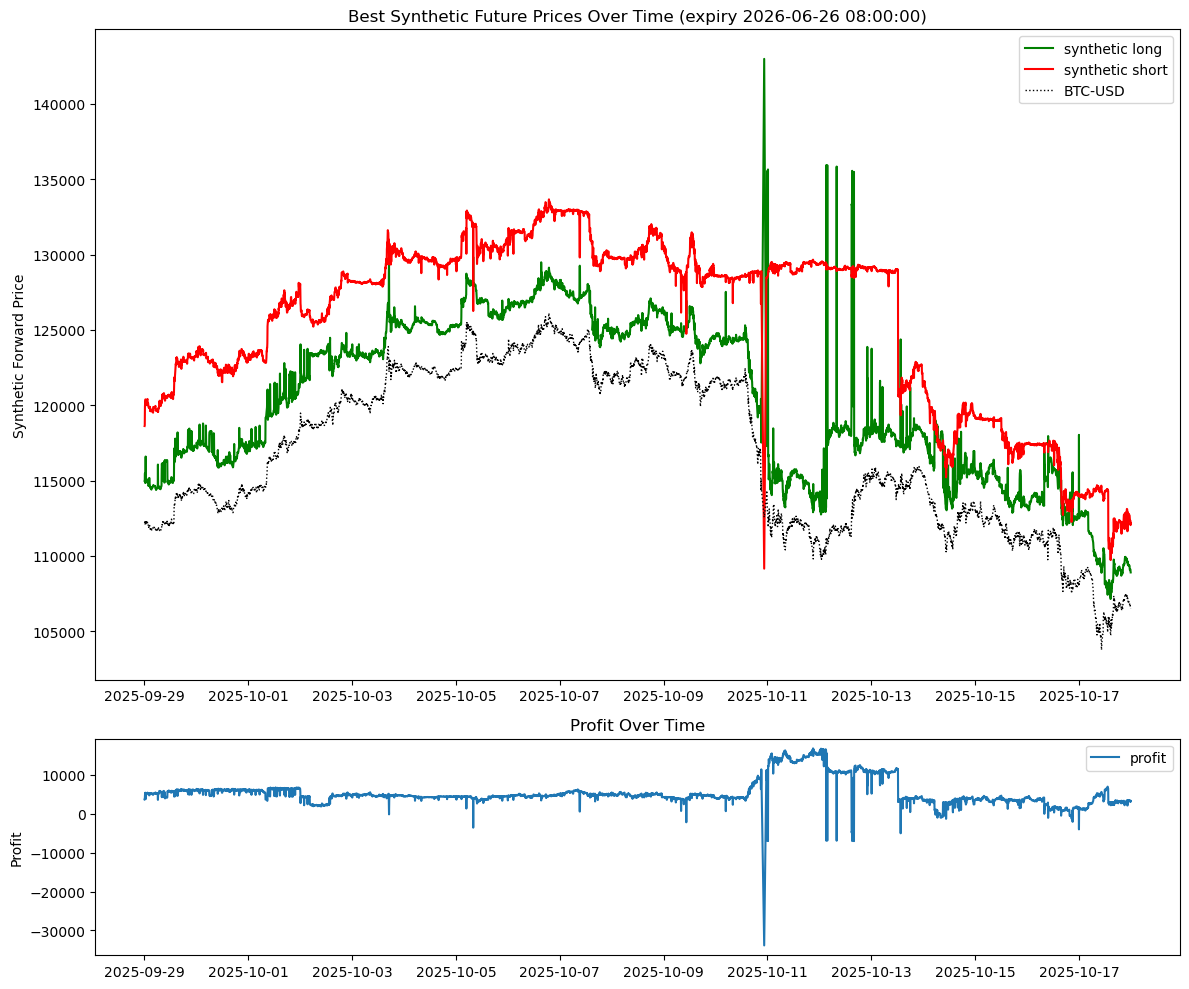

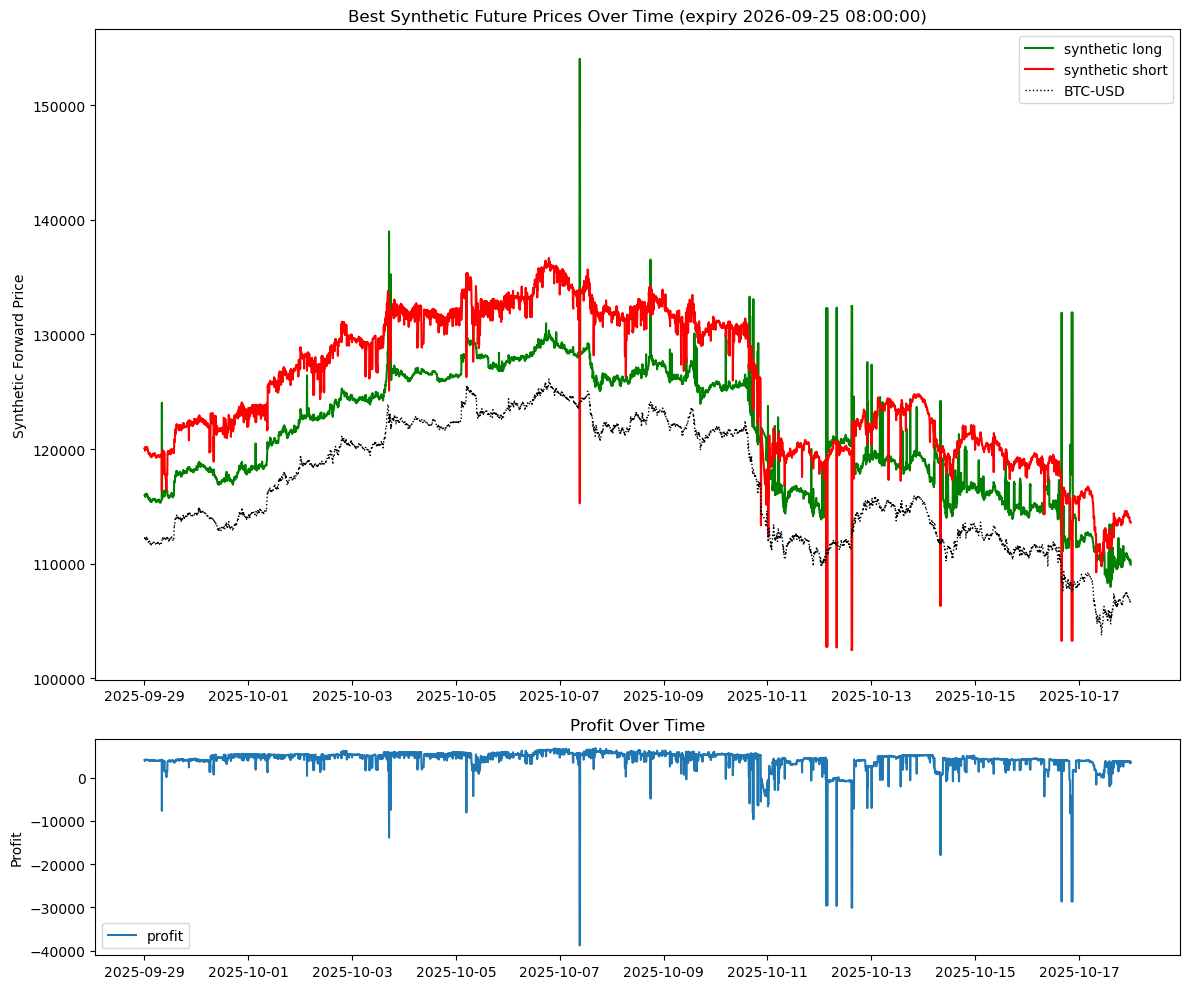

In [7]:
for expiry in aggregated_5m['expiry'].unique():
    df = aggregated_5m.filter(pl.col('expiry') == expiry)
    plot(df, expiry)

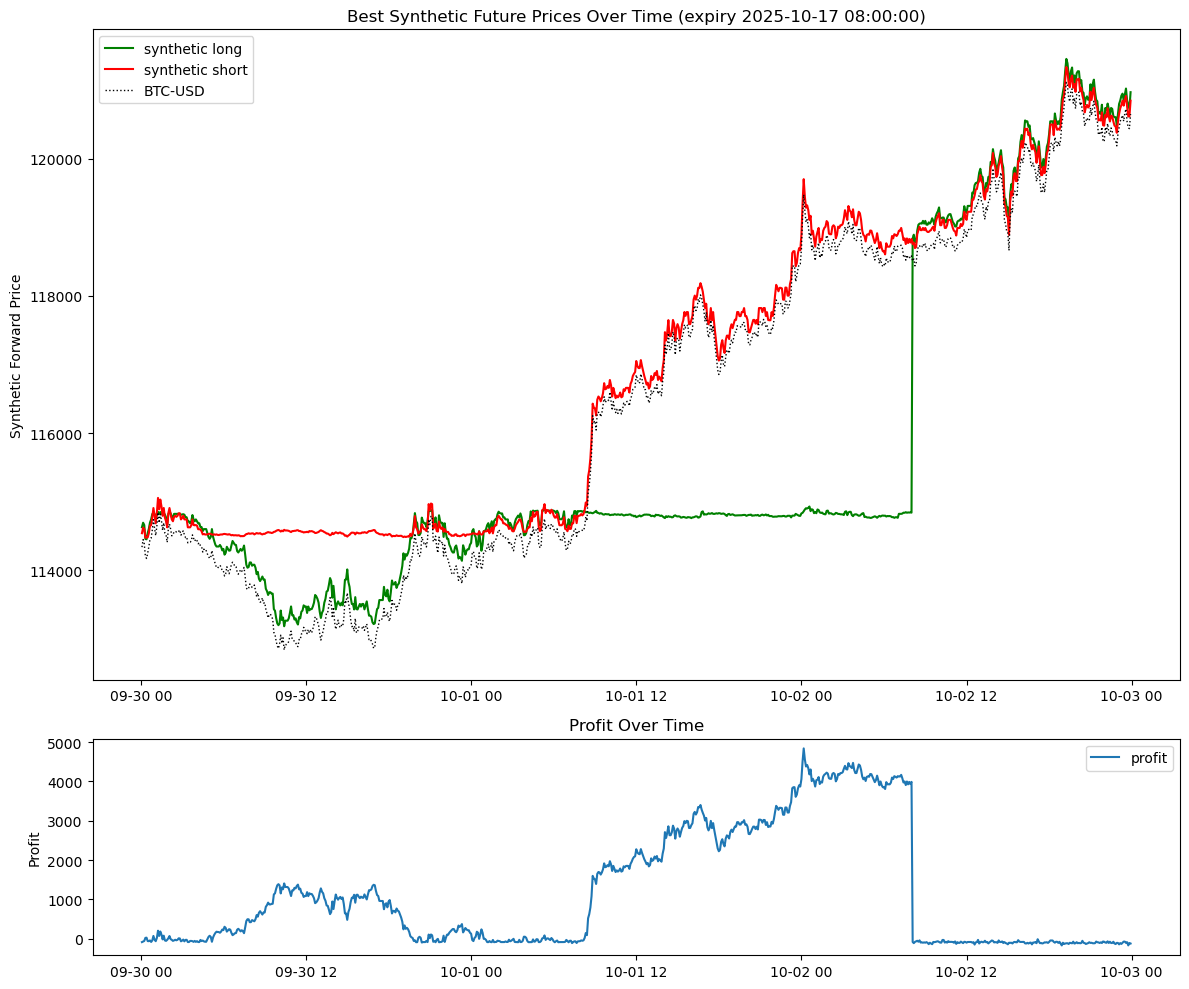

In [36]:
expiry_list = aggregated_5m['expiry'].unique()
inspect_expiry = expiry_list[17]
inspect_start = datetime(2025, 9, 30, 0, 0, 0)
inspect_end = datetime(2025, 10, 3, 0, 0, 0)
df = aggregated_5m.filter(pl.col('expiry') == inspect_expiry).filter(pl.col('timeMs') > inspect_start).filter(pl.col('timeMs') < inspect_end)
plot(df, inspect_expiry)

In [19]:
filtered = aggregated_5m.filter(pl.col('expiry') == inspect_expiry).filter(pl.col('timeMs') > inspect_start).filter(pl.col('timeMs') < inspect_end).sort('timeMs')
selected = filtered.select('timeMs', 'expiry', 'BTC-USD', 'short_fwd', 'short_strike', 'short_call_bid', 'short_put_ask', 'long_fwd', 'long_strike', 'long_call_ask', 'long_put_bid', 'profit_per_unit')
# Compute the first and last entry for every contiguous block in long/short_strike

def get_blocks(df, column):
    blocks = df.with_columns([
        (pl.col(column) != pl.col(column).shift(1)).cum_sum().alias('block')
    ])
    blocks = blocks.join(
        blocks.group_by('block').count().rename({'count': 'block_length'}),
        on='block'
    )
    blocks = pl.concat([
        blocks.group_by('block').first(),
        blocks.group_by('block').last()
    ]).sort('timeMs')
    return blocks

short_blocks = get_blocks(selected, 'short_strike').select('block', 'block_length', 'timeMs', 'short_strike', 'short_call_bid', 'short_put_ask', 'short_fwd', 'BTC-USD', 'profit_per_unit')
long_blocks = get_blocks(selected, 'long_strike').select('block', 'block_length', 'timeMs', 'long_strike', 'long_call_ask', 'long_put_bid', 'long_fwd', 'BTC-USD', 'profit_per_unit')
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print('Short blocks:')
    print(short_blocks.filter(pl.col('block_length') > 100))
    print('Long blocks:')
    print(long_blocks.filter(pl.col('block_length') > 100))

Short blocks:
shape: (2, 9)
┌───────┬───────────┬───────────┬───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ block ┆ block_len ┆ timeMs    ┆ short_str ┆ short_ca ┆ short_pu ┆ short_fw ┆ BTC-USD  ┆ profit_p │
│ ---   ┆ gth       ┆ ---       ┆ ike       ┆ ll_bid   ┆ t_ask    ┆ d        ┆ ---      ┆ er_unit  │
│ u32   ┆ ---       ┆ datetime[ ┆ ---       ┆ ---      ┆ ---      ┆ ---      ┆ f64      ┆ ---      │
│       ┆ u32       ┆ ms]       ┆ i64       ┆ f64      ┆ f64      ┆ f64      ┆          ┆ f64      │
╞═══════╪═══════════╪═══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 56    ┆ 137       ┆ 2025-09-3 ┆ 128000    ┆ 0.0026   ┆ 0.121    ┆ 114529.2 ┆ 113743.9 ┆ 446.9706 │
│       ┆           ┆ 0         ┆           ┆          ┆          ┆ 01632    ┆ 5        ┆ 02       │
│       ┆           ┆ 07:40:00  ┆           ┆          ┆          ┆          ┆          ┆          │
│ 56    ┆ 137       ┆ 2025-09-3 ┆ 128000    ┆ 0.0023   ┆ 0.121 

/var/folders/fl/fdwpgpsx7fx15p__07t93bhr0000gn/T/ipykernel_67818/2532040178.py:10: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  blocks.group_by('block').count().rename({'count': 'block_length'}),


In this case, the profit is due to the underpriced asks on the calls at strikes 108750 and 109250

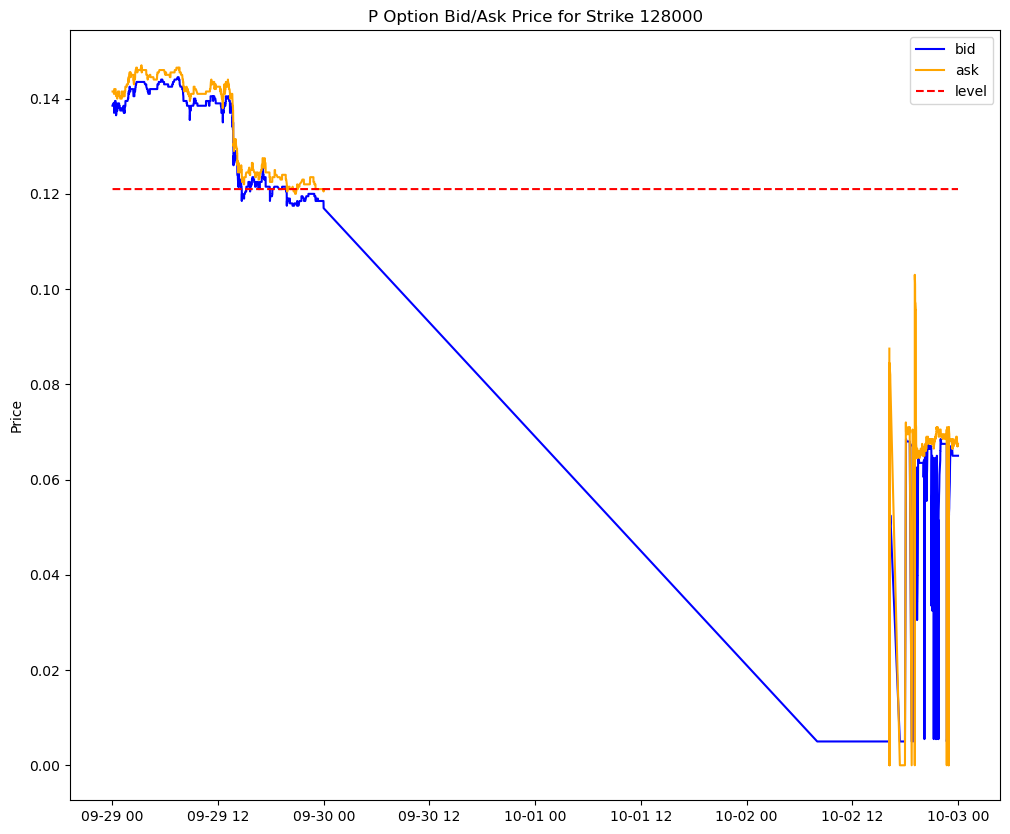

In [26]:
inspect_dates = [date(2025, 9, 29), date(2025, 9, 30), date(2025, 10, 1), date(2025, 10, 2)]
inspect_strike = 128000
inspect_side = 'P'
inspect_level = 0.121
inspect_level_side = 'bid'
options_lf = store.get(
    inst_family = 'BTC-USD',
    inst_type = 'OPTION',
    dates = inspect_dates,
    depth = 1,
    features = ['trim', 'parse_option', 'tenor', 'times_to_dt'],
    cache_name = 'test_pc_3'
)
# No binning
options_lf = options_lf.filter(pl.col('expiry') == inspect_expiry).sort('timeMs')
strike = options_lf.filter((pl.col('strike') == inspect_strike) & (pl.col('opt_type') == inspect_side)).sort('timeMs').select('timeMs', 'opt_type', 'strike', 'bid_1_px', 'ask_1_px').collect()

def test_plt(df, level):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(df['timeMs'], df['bid_1_px'], label='bid', color='blue')
    ax.plot(df['timeMs'], df['ask_1_px'], label='ask', color='orange')
    ax.plot(df['timeMs'], [level]*len(df), label='level', linestyle='--', color='red')
    ax.set_ylabel('Price')
    opt_type = df["opt_type"].unique()[0]
    strike = df["strike"].unique()[0]
    ax.set_title(f'{opt_type} Option Bid/Ask Price for Strike {strike}')
    ax.legend()
    plt.show()

test_plt(strike, inspect_level)



In [24]:
print(options_lf.sort('timeMs').head(10).collect())

shape: (10, 13)
┌─────────────┬────────────┬────────────┬──────────┬───┬────────┬──────────┬────────────┬──────────┐
│ timeMs      ┆ exchTimeMs ┆ symbol     ┆ bid_1_px ┆ … ┆ strike ┆ opt_type ┆ expiry     ┆ T        │
│ ---         ┆ ---        ┆ ---        ┆ ---      ┆   ┆ ---    ┆ ---      ┆ ---        ┆ ---      │
│ datetime[ms ┆ datetime[m ┆ str        ┆ f64      ┆   ┆ i64    ┆ str      ┆ datetime[m ┆ f64      │
│ ]           ┆ s]         ┆            ┆          ┆   ┆        ┆          ┆ s]         ┆          │
╞═════════════╪════════════╪════════════╪══════════╪═══╪════════╪══════════╪════════════╪══════════╡
│ 2025-09-30  ┆ 2025-09-30 ┆ BTC-USD-25 ┆ 0.045    ┆ … ┆ 118000 ┆ P        ┆ 2025-10-17 ┆ 0.047489 │
│ 00:00:00.02 ┆ 00:00:00.0 ┆ 1017-11800 ┆          ┆   ┆        ┆          ┆ 08:00:00   ┆          │
│ 4           ┆ 21         ┆ 0-P.OK     ┆          ┆   ┆        ┆          ┆            ┆          │
│ 2025-09-30  ┆ 2025-09-30 ┆ BTC-USD-25 ┆ 0.005    ┆ … ┆ 104000 ┆ P        

In [28]:
raw_blocks = get_blocks(strike, f'{inspect_level_side}_1_px')
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(raw_blocks.sort('timeMs'))


shape: (1_516, 7)
┌───────┬─────────────────────────┬──────────┬────────┬──────────┬──────────┬──────────────┐
│ block ┆ timeMs                  ┆ opt_type ┆ strike ┆ bid_1_px ┆ ask_1_px ┆ block_length │
│ ---   ┆ ---                     ┆ ---      ┆ ---    ┆ ---      ┆ ---      ┆ ---          │
│ u32   ┆ datetime[ms]            ┆ str      ┆ i64    ┆ f64      ┆ f64      ┆ u32          │
╞═══════╪═════════════════════════╪══════════╪════════╪══════════╪══════════╪══════════════╡
│ 0     ┆ 2025-09-29 00:01:33.372 ┆ P        ┆ 128000 ┆ 0.1385   ┆ 0.1415   ┆ 1            │
│ 0     ┆ 2025-09-29 00:01:33.372 ┆ P        ┆ 128000 ┆ 0.1385   ┆ 0.1415   ┆ 1            │
│ 1     ┆ 2025-09-29 00:05:55.836 ┆ P        ┆ 128000 ┆ 0.139    ┆ 0.1415   ┆ 13           │
│ 1     ┆ 2025-09-29 00:10:00.297 ┆ P        ┆ 128000 ┆ 0.139    ┆ 0.141    ┆ 13           │
│ 2     ┆ 2025-09-29 00:10:26.037 ┆ P        ┆ 128000 ┆ 0.1385   ┆ 0.141    ┆ 3            │
│ 2     ┆ 2025-09-29 00:11:21.677 ┆ P        ┆ 12800

/var/folders/fl/fdwpgpsx7fx15p__07t93bhr0000gn/T/ipykernel_67818/2532040178.py:10: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  blocks.group_by('block').count().rename({'count': 'block_length'}),


In [37]:
filtered = strike.filter((pl.col('timeMs') > datetime(2025, 9, 29, 23, 50, 0)) & (pl.col('timeMs') < datetime(2025, 10, 2, 9, 0, 0)))
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(filtered)

shape: (16, 5)
┌─────────────────────────┬──────────┬────────┬──────────┬──────────┐
│ timeMs                  ┆ opt_type ┆ strike ┆ bid_1_px ┆ ask_1_px │
│ ---                     ┆ ---      ┆ ---    ┆ ---      ┆ ---      │
│ datetime[ms]            ┆ str      ┆ i64    ┆ f64      ┆ f64      │
╞═════════════════════════╪══════════╪════════╪══════════╪══════════╡
│ 2025-09-29 23:52:06.893 ┆ P        ┆ 128000 ┆ 0.1185   ┆ 0.121    │
│ 2025-09-29 23:56:58.613 ┆ P        ┆ 128000 ┆ 0.1185   ┆ 0.121    │
│ 2025-09-29 23:57:55.432 ┆ P        ┆ 128000 ┆ 0.1185   ┆ 0.1205   │
│ 2025-09-29 23:58:01.282 ┆ P        ┆ 128000 ┆ 0.1185   ┆ 0.1205   │
│ 2025-09-29 23:58:19.645 ┆ P        ┆ 128000 ┆ 0.118    ┆ 0.1205   │
│ 2025-09-29 23:58:19.653 ┆ P        ┆ 128000 ┆ 0.118    ┆ 0.1205   │
│ 2025-09-29 23:58:25.265 ┆ P        ┆ 128000 ┆ 0.117    ┆ 0.1205   │
│ 2025-09-29 23:58:25.383 ┆ P        ┆ 128000 ┆ 0.117    ┆ 0.121    │
│ 2025-09-29 23:58:51.593 ┆ P        ┆ 128000 ┆ 0.117    ┆ 0.121    │
│ 202

In [83]:
store.clear_cache()

Cleared all caches


In [42]:
# ['trim', 'nullify', 'bin_ff', 'sink_bins', 'drop_nulls_strict', 'parse_option', 'tenor']
options_binned = store.get(
    inst_family = 'BTC-USD',
    inst_type = 'OPTION',
    dates = [date(2025, 8, 17), date(2025, 8, 18)],
    depth = 1,
    binning = '5m',
    features = ['trim', 'bin_ff', 'nullify', 'drop_nulls_strict', 'parse_option', 'tenor', 'times_to_dt']
)

options_binned = options_binned.filter(pl.col('expiry') == expiry_list[2]).sort('timeMs')
options_binned = options_binned.filter(pl.col('strike') == 120000)
options_binned = options_binned.filter(pl.col('opt_type') == 'P')
options_binned = options_binned.select('timeMs', 'time_bin', 'opt_type', 'strike', 'bid_1_px', 'ask_1_px').sort('timeMs')


blocks_binned = options_binned.with_columns([
    (pl.col('ask_1_px') != pl.col('ask_1_px').shift(1)).cum_sum().alias('block')
])
# Get one block df with only first and last entry of each block, concatted, time sorted
firsts_binned = blocks_binned.group_by('block').first()
lasts_binned = blocks_binned.group_by('block').last()
trim_df_binned = pl.concat([firsts_binned, lasts_binned]).sort('timeMs').collect()
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(trim_df_binned)


shape: (86, 7)
┌───────┬─────────────────────────┬─────────────────────┬──────────┬────────┬──────────┬──────────┐
│ block ┆ timeMs                  ┆ time_bin            ┆ opt_type ┆ strike ┆ bid_1_px ┆ ask_1_px │
│ ---   ┆ ---                     ┆ ---                 ┆ ---      ┆ ---    ┆ ---      ┆ ---      │
│ u32   ┆ datetime[ms]            ┆ datetime[ms]        ┆ str      ┆ i64    ┆ f64      ┆ f64      │
╞═══════╪═════════════════════════╪═════════════════════╪══════════╪════════╪══════════╪══════════╡
│ null  ┆ 2025-08-17 16:34:53.021 ┆ 2025-08-17 16:35:00 ┆ P        ┆ 120000 ┆ 0.0185   ┆ 0.0195   │
│ null  ┆ 2025-08-17 16:34:53.021 ┆ 2025-08-17 16:35:00 ┆ P        ┆ 120000 ┆ 0.0185   ┆ 0.0195   │
│ 1     ┆ 2025-08-17 16:39:59.021 ┆ 2025-08-17 16:40:00 ┆ P        ┆ 120000 ┆ 0.01     ┆ 0.02     │
│ 1     ┆ 2025-08-17 16:39:59.021 ┆ 2025-08-17 16:40:00 ┆ P        ┆ 120000 ┆ 0.01     ┆ 0.02     │
│ 2     ┆ 2025-08-17 16:44:57.841 ┆ 2025-08-17 16:45:00 ┆ P        ┆ 120000 ┆ 0.016  

In [43]:
filtered = options_binned.filter((pl.col('timeMs') > datetime(2025, 8, 17, 23, 50, 0)) & (pl.col('timeMs') < datetime(2025, 8, 18, 1, 0, 0))).collect()
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(filtered)

shape: (2, 6)
┌─────────────────────────┬─────────────────────┬──────────┬────────┬──────────┬──────────┐
│ timeMs                  ┆ time_bin            ┆ opt_type ┆ strike ┆ bid_1_px ┆ ask_1_px │
│ ---                     ┆ ---                 ┆ ---      ┆ ---    ┆ ---      ┆ ---      │
│ datetime[ms]            ┆ datetime[ms]        ┆ str      ┆ i64    ┆ f64      ┆ f64      │
╞═════════════════════════╪═════════════════════╪══════════╪════════╪══════════╪══════════╡
│ 2025-08-17 23:52:28.078 ┆ 2025-08-17 23:55:00 ┆ P        ┆ 120000 ┆ 0.0215   ┆ 0.024    │
│ 2025-08-17 23:52:28.078 ┆ 2025-08-18 00:00:00 ┆ P        ┆ 120000 ┆ 0.0215   ┆ 0.024    │
└─────────────────────────┴─────────────────────┴──────────┴────────┴──────────┴──────────┘
